# 🧬 MARS500 Gut Microbiome — Comprehensive Exploratory Data Analysis

## What Is This Study About?

Imagine being locked inside a sealed building with five other people for **520 days** — almost a year and a half — with no
sunlight, no fresh air, and no way to leave. That is exactly what six male volunteers experienced during the **MARS500**
experiment (2010–2011), the longest high-fidelity simulation of a crewed Mars mission ever conducted. The project, a
collaboration between the **Russian Academy of Sciences (IBMP)**, the **European Space Agency (ESA)**, and China's space
program, aimed to study how prolonged isolation and confinement affect human physiology and psychology.

One of the most fascinating — and medically important — questions that emerged from this study is:

> **What happens to the trillions of bacteria living inside the human gut when their host is confined for over 500 days?**

### Why Does This Matter?

The **gut microbiome** — the community of bacteria, archaea, and other microorganisms residing in the gastrointestinal
tract — is now recognized as a critical organ system. It plays key roles in:

| Function | Description |
|---|---|
| **Digestion & Nutrition** | Breaks down dietary fibers into short-chain fatty acids (SCFAs) that feed intestinal cells |
| **Immune Regulation** | Trains and modulates the immune system, preventing autoimmune reactions |
| **Mental Health** | Produces neurotransmitters (serotonin, GABA) that influence mood via the gut-brain axis |
| **Pathogen Defense** | Competes with harmful bacteria, preventing colonization by pathogens |
| **Metabolic Health** | Regulates fat storage, blood sugar, and inflammation |

Understanding how the microbiome responds to prolonged confinement is directly relevant to:
- **Future Mars missions** (estimated 2.5+ years round-trip)
- **Submarine crews and Antarctic researchers** who endure months of isolation
- **Hospital patients** and **prison populations** in long-term confinement
- **Pandemic lockdowns** and their gut-health consequences

### The Dataset: NASA GeneLab GLDS-191

This dataset is publicly available through NASA's Open Science Data Repository as
[GLDS-191 / OSD-191](https://osdr.nasa.gov/bio/repo/data/studies/OSD-191).
The original study was published by Turroni et al. (2017) in *PLOS ONE*.

**What was collected:**
Fecal samples from 6 crew members at multiple timepoints spanning before, during, and after the 520-day isolation period.
Bacterial DNA was extracted and the **16S rRNA gene** (a universal bacterial identification barcode) was sequenced using
**Illumina** technology. The GeneLab team then processed the raw sequences through their standardized amplicon pipeline,
producing the **Amplicon Sequence Variant (ASV)** tables we analyze here.

---

## What Is 16S rRNA Sequencing?

All bacteria carry a gene called **16S rRNA** — it is part of the protein-making machinery (ribosome) of every bacterial
cell. This gene is special because:

1. **It is universal** — present in all bacteria and archaea
2. **It has conserved regions** — allowing universal PCR primers to amplify it
3. **It has variable regions** — allowing us to distinguish between different species

Think of it like a bacterial fingerprint. By sequencing this gene from all bacteria in a stool sample, we can identify
*who* is present and in *what proportions* — without needing to culture anything in a lab.

**ASVs (Amplicon Sequence Variants)** are the modern replacement for the older "OTU" approach. Each ASV represents a
unique DNA sequence, providing single-nucleotide resolution — meaning we can distinguish bacteria that differ by even
one DNA base pair.

---

## 1. Setup and Data Loading

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# Paths
BASE = os.path.dirname(os.path.abspath('__file__'))
if os.path.basename(BASE) != 'research':
    # Try to find the research directory
    for candidate in [BASE, os.path.join(BASE, 'research')]:
        if os.path.exists(os.path.join(candidate, 'data', 'processed')):
            BASE = candidate
            break

DATA   = os.path.join(BASE, 'data', 'processed')
META   = os.path.join(BASE, 'data', 'metadata')
TABLES = os.path.join(BASE, 'results', 'tables')
FIGS   = os.path.join(BASE, 'results', 'figures')
PICRUST = os.path.join(BASE, 'results', 'picrust2', 'pathways_out')

print(f"📂 Project root: {BASE}")

📂 Project root: /Users/hamzaelghonemy/Desktop/University/Senior/Bioinformatics II/research


In [2]:
# Load core data files
counts_df = pd.read_csv(os.path.join(DATA, 'GLDS-191_GAmplicon_counts.tsv'), sep='\t', index_col=0)
taxonomy_df = pd.read_csv(os.path.join(DATA, 'GLDS-191_GAmplicon_taxonomy.tsv'), sep='\t', index_col=0)
metadata_df = pd.read_csv(os.path.join(META, 'processed_metadata.tsv'), sep='\t', index_col=0)

# Fix Windows line endings if present
counts_df.columns = [c.strip() for c in counts_df.columns]
taxonomy_df.columns = [c.strip() for c in taxonomy_df.columns]

print("✅ All core data files loaded successfully!")
print(f"\n📊 Dataset dimensions:")
print(f"   ASV count table : {counts_df.shape[0]:,} ASVs × {counts_df.shape[1]:,} samples")
print(f"   Taxonomy table  : {taxonomy_df.shape[0]:,} ASVs × {taxonomy_df.shape[1]} ranks")
print(f"   Metadata table  : {metadata_df.shape[0]:,} samples × {metadata_df.shape[1]} columns")

✅ All core data files loaded successfully!

📊 Dataset dimensions:
   ASV count table : 2,916 ASVs × 159 samples
   Taxonomy table  : 2,916 ASVs × 7 ranks
   Metadata table  : 159 samples × 4 columns


## 2. Understanding the Metadata — Who, When, and What Phase?

The 520-day isolation was divided into **5 mission phases** based on the timeline of the simulated Mars mission:

| Phase | Days | Description |
|---|---|---|
| **Pre-Mission** | Before Day 0 | Baseline samples before the hatch closed |
| **Early** | Days 1–45 | Initial adaptation to confinement |
| **Mid** | Days 46–340 | The long cruise — simulated travel to Mars and surface operations |
| **Late** | Days 341–520 | Final stretch — simulated return journey, fatigue accumulation |
| **Post-Mission** | After Day 520 | Recovery samples after the crew exited confinement |

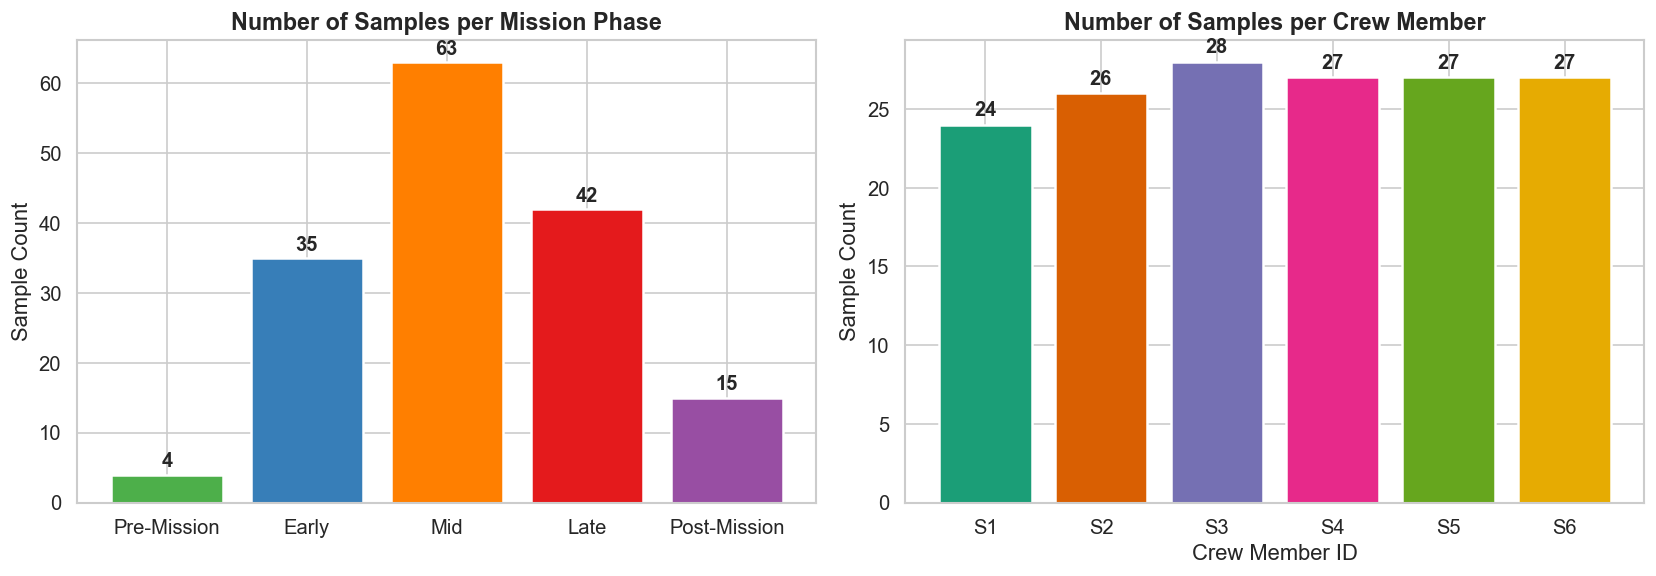


📋 Sample breakdown by phase:
   Pre-Mission    :   4 samples
   Early          :  35 samples
   Mid            :  63 samples
   Late           :  42 samples
   Post-Mission   :  15 samples

👥 Crew members: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
📅 Timepoints range: Day -10 to Day 700


In [3]:
# Phase and crew distribution
phase_order = ['Pre-Mission', 'Early', 'Mid', 'Late', 'Post-Mission']
metadata_df['Phase'] = pd.Categorical(metadata_df['Phase'], categories=phase_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phase_colors = {'Pre-Mission': '#4DAF4A', 'Early': '#377EB8', 'Mid': '#FF7F00',
                'Late': '#E41A1C', 'Post-Mission': '#984EA3'}

# Phase distribution
phase_counts = metadata_df['Phase'].value_counts().reindex(phase_order)
bars = axes[0].bar(phase_counts.index, phase_counts.values,
                   color=[phase_colors[p] for p in phase_counts.index], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, phase_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Number of Samples per Mission Phase', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].set_xlabel('')

# Crew distribution
crew_counts = metadata_df['CrewMember'].value_counts().sort_index()
axes[1].bar(crew_counts.index, crew_counts.values, color=sns.color_palette('Dark2', len(crew_counts)),
            edgecolor='white', linewidth=1.5)
for i, (crew, val) in enumerate(crew_counts.items()):
    axes[1].text(i, val + 0.3, str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Number of Samples per Crew Member', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Sample Count')
axes[1].set_xlabel('Crew Member ID')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_sample_distribution.png'), bbox_inches='tight')
plt.show()

print(f"\n📋 Sample breakdown by phase:")
for phase in phase_order:
    n = (metadata_df['Phase'] == phase).sum()
    print(f"   {phase:15s}: {n:3d} samples")
print(f"\n👥 Crew members: {sorted(metadata_df['CrewMember'].unique())}")
print(f"📅 Timepoints range: Day {metadata_df['Timepoint_Day'].min()} to Day {metadata_df['Timepoint_Day'].max()}")

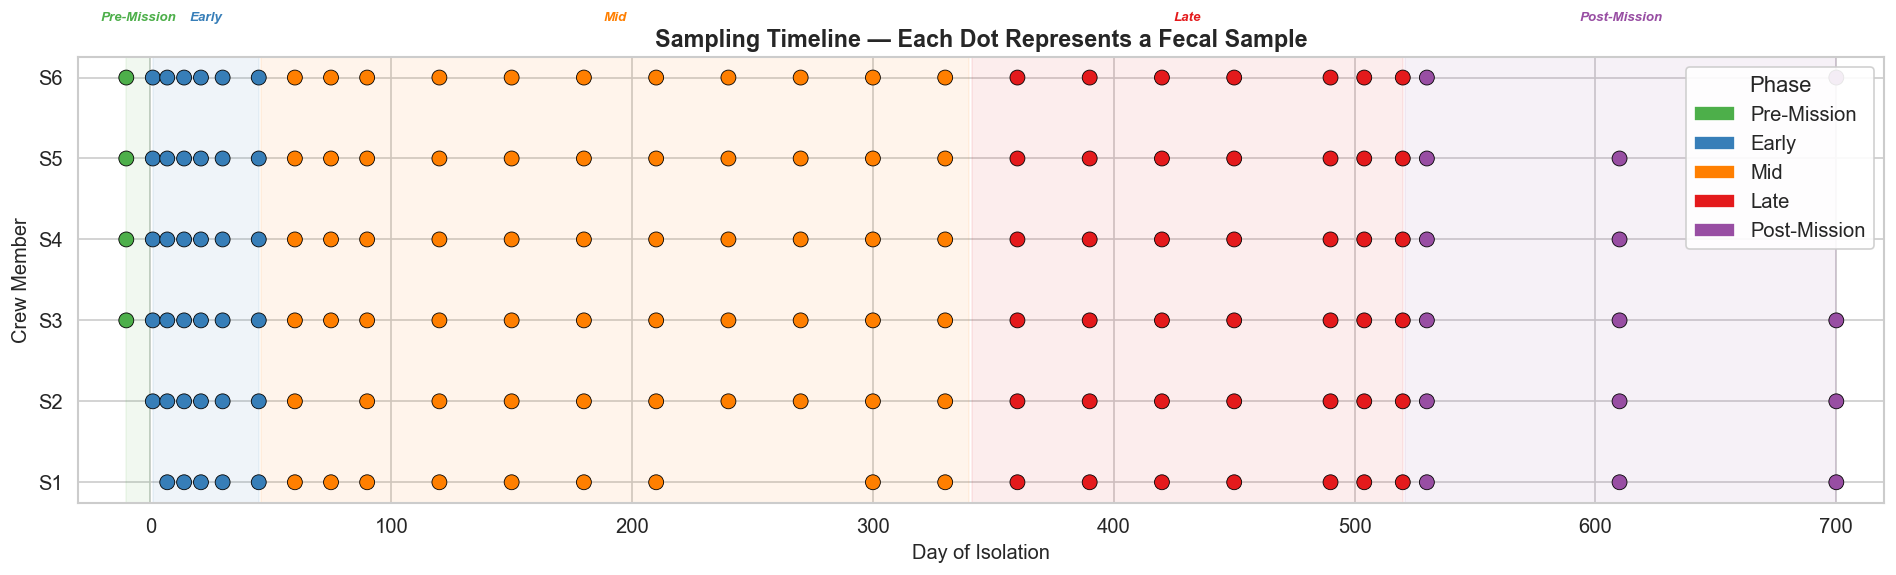

In [4]:
# Timeline visualization — when was each crew member sampled?
fig, ax = plt.subplots(figsize=(16, 5))
crew_list = sorted(metadata_df['CrewMember'].unique())
crew_palette = dict(zip(crew_list, sns.color_palette('Dark2', len(crew_list))))

for i, crew in enumerate(crew_list):
    subset = metadata_df[metadata_df['CrewMember'] == crew]
    ax.scatter(subset['Timepoint_Day'], [i]*len(subset), c=[phase_colors[p] for p in subset['Phase']],
               s=80, edgecolors='black', linewidth=0.5, zorder=3)

# Phase background shading
phase_spans = [(-10, 0), (1, 45), (46, 340), (341, 520), (521, 700)]
for (start, end), phase in zip(phase_spans, phase_order):
    ax.axvspan(start, end, alpha=0.08, color=phase_colors[phase])
    ax.text((start+end)/2, len(crew_list)-0.3, phase, ha='center', fontsize=8, fontstyle='italic',
            color=phase_colors[phase], fontweight='bold')

ax.set_yticks(range(len(crew_list)))
ax.set_yticklabels(crew_list)
ax.set_xlabel('Day of Isolation', fontsize=12)
ax.set_ylabel('Crew Member', fontsize=12)
ax.set_title('Sampling Timeline — Each Dot Represents a Fecal Sample', fontsize=14, fontweight='bold')
ax.set_xlim(-30, 720)
legend_elements = [mpatches.Patch(facecolor=phase_colors[p], label=p) for p in phase_order]
ax.legend(handles=legend_elements, loc='upper right', title='Phase', framealpha=0.9)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_sampling_timeline.png'), bbox_inches='tight')
plt.show()

### Key Observation
Notice the **uneven sampling density** — the Pre-Mission phase has only **4 samples** (one per available crew member
at baseline), while the Mid phase has **63 samples** because it spans the longest period (almost 300 days).
This imbalance is important to keep in mind when interpreting statistical tests.

## 3. Taxonomic Overview — What Bacteria Are Present?

### The Tree of Life in Your Gut
Bacteria are classified into a hierarchy, much like animals or plants:

**Domain → Phylum → Class → Order → Family → Genus → Species**

In this dataset, most ASVs could be classified down to the **family** or **genus** level, but many remain unidentified
at the species level — this is normal for 16S amplicon data, which typically resolves to genus level.

In [5]:
print("🧬 Taxonomic Classification Summary")
print("=" * 50)
for rank in taxonomy_df.columns:
    n_known = taxonomy_df[rank].notna().sum() - (taxonomy_df[rank] == 'NA').sum()
    n_total = len(taxonomy_df)
    pct = n_known / n_total * 100
    n_unique = taxonomy_df[rank].replace('NA', np.nan).dropna().nunique()
    print(f"   {rank:10s}: {n_known:,}/{n_total:,} classified ({pct:.1f}%) — {n_unique:,} unique")

🧬 Taxonomic Classification Summary
   domain    : 2,859/2,916 classified (98.0%) — 2 unique
   phylum    : 2,692/2,916 classified (92.3%) — 11 unique
   class     : 2,612/2,916 classified (89.6%) — 18 unique
   order     : 2,222/2,916 classified (76.2%) — 39 unique
   family    : 1,928/2,916 classified (66.1%) — 62 unique
   genus     : 1,257/2,916 classified (43.1%) — 176 unique
   species   : 0/2,916 classified (0.0%) — 0 unique


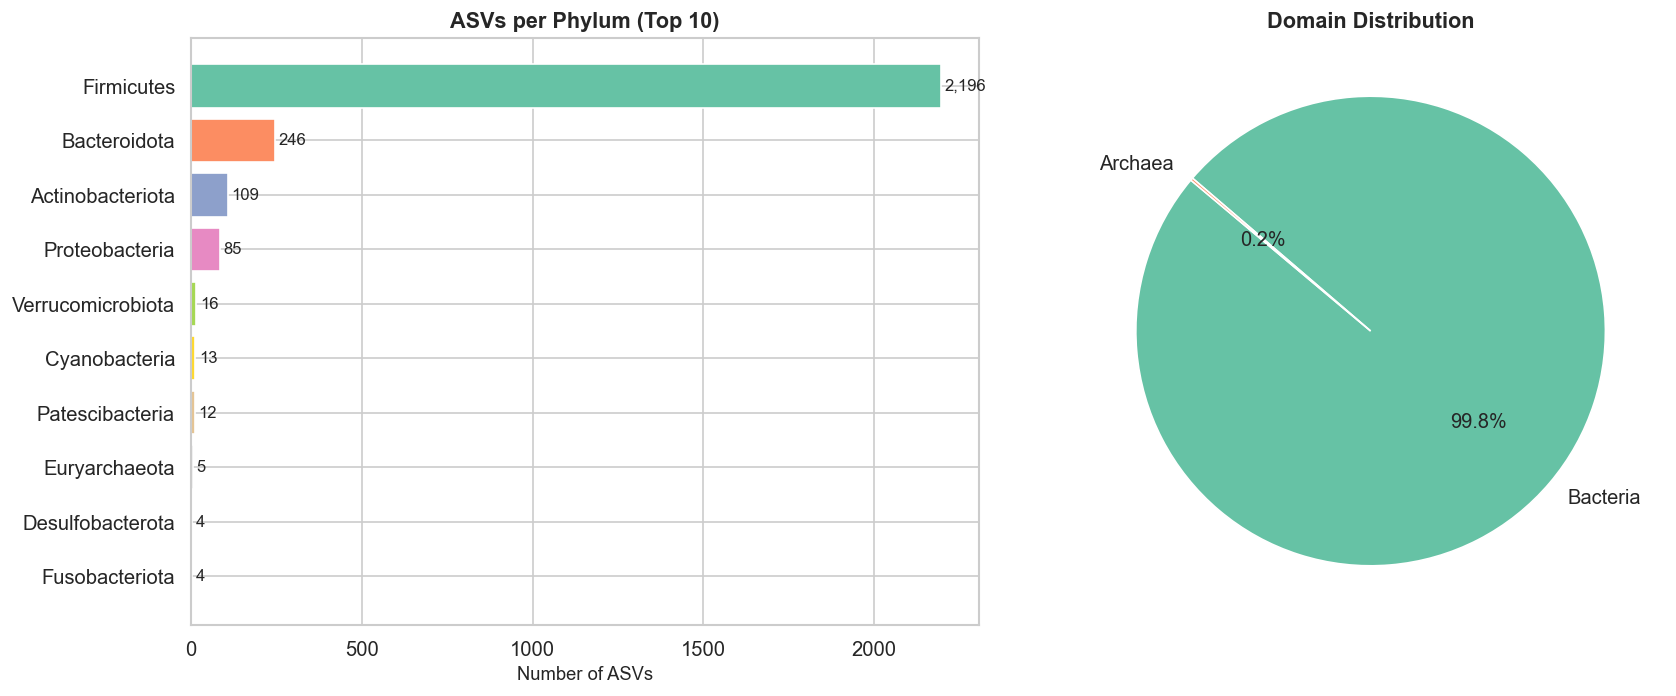

In [6]:
# Phylum-level composition
tax_clean = taxonomy_df.copy()
tax_clean = tax_clean.replace('NA', np.nan)

phylum_counts = tax_clean['phylum'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart of ASVs per phylum
top_phyla = phylum_counts.head(10)
colors_phyla = sns.color_palette('Set2', len(top_phyla))
bars = axes[0].barh(top_phyla.index[::-1], top_phyla.values[::-1], color=colors_phyla[::-1], edgecolor='white')
axes[0].set_xlabel('Number of ASVs', fontsize=11)
axes[0].set_title('ASVs per Phylum (Top 10)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_phyla.values[::-1]):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

# Pie chart of domain-level
domain_counts = tax_clean['domain'].value_counts()
axes[1].pie(domain_counts.values, labels=domain_counts.index, autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62', '#8da0cb'], startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Domain Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_taxonomy_overview.png'), bbox_inches='tight')
plt.show()

### What Do These Phyla Mean?

| Phylum | Role in the Gut | Typical Members |
|---|---|---|
| **Firmicutes** | Dominant phylum; many fiber-fermenters producing butyrate (an anti-inflammatory fatty acid) | *Faecalibacterium*, *Ruminococcus*, *Lachnospira* |
| **Bacteroidota** | Breaks down complex carbohydrates and proteins; produces propionate | *Bacteroides*, *Prevotella*, *Parabacteroides* |
| **Actinobacteriota** | Includes beneficial bifidobacteria; important for immune development | *Bifidobacterium*, *Collinsella* |
| **Proteobacteria** | Often called "pathobionts" — normally low in healthy guts; bloom = dysbiosis marker | *Escherichia*, *Sutterella*, *Bilophila* |
| **Verrucomicrobiota** | Mucin-degrading specialists that strengthen the gut lining | *Akkermansia muciniphila* |

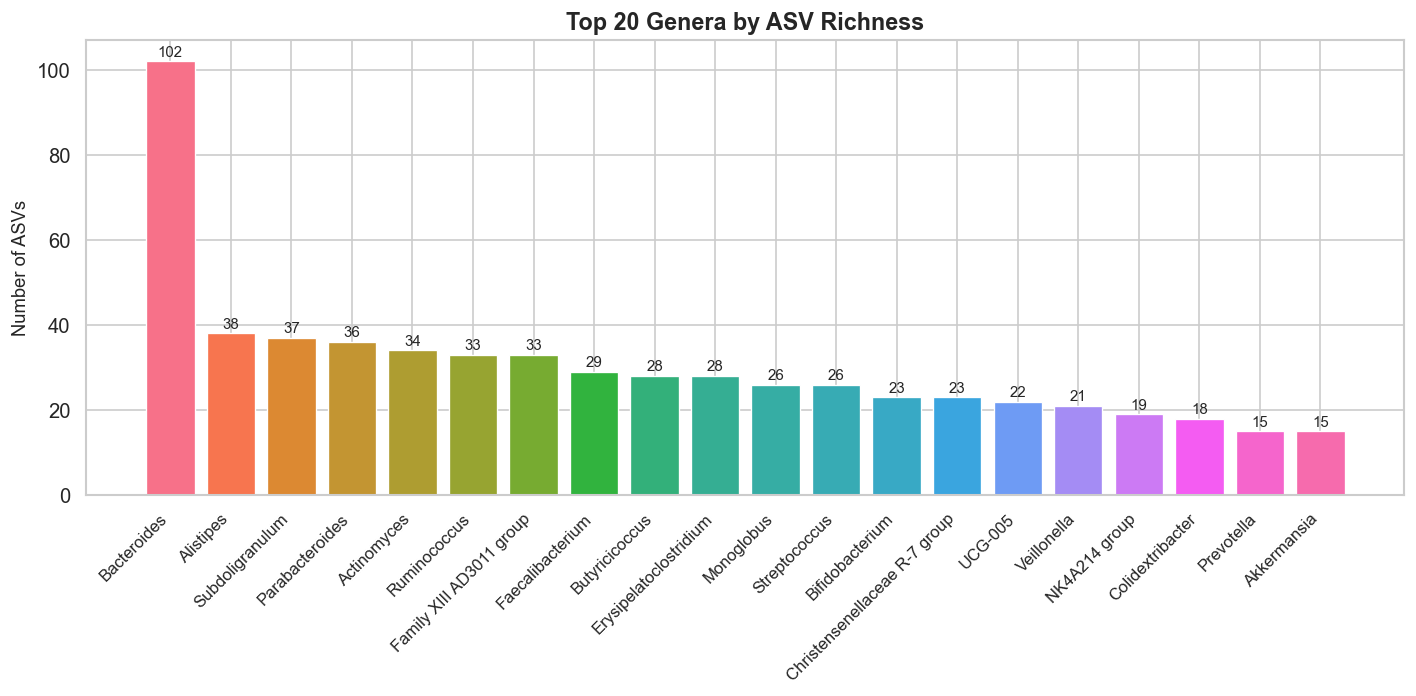

In [7]:
# Genus-level landscape — top 20 most ASV-rich genera
genus_counts = tax_clean['genus'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(genus_counts)), genus_counts.values,
              color=sns.color_palette('husl', len(genus_counts)), edgecolor='white', linewidth=0.8)
ax.set_xticks(range(len(genus_counts)))
ax.set_xticklabels(genus_counts.index, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Number of ASVs', fontsize=11)
ax.set_title('Top 20 Genera by ASV Richness', fontsize=14, fontweight='bold')
ax.set_xlabel('')
for bar, val in zip(bars, genus_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_top_genera.png'), bbox_inches='tight')
plt.show()

## 4. Sequencing Depth — How Well Was Each Sample Sequenced?

**Sequencing depth** (also called library size) is the total number of sequencing reads obtained per sample.
Higher depth = more thorough sampling of the bacterial community. If some samples have much lower depth,
they may appear to have lower diversity simply because rare bacteria were missed — not because they are truly absent.

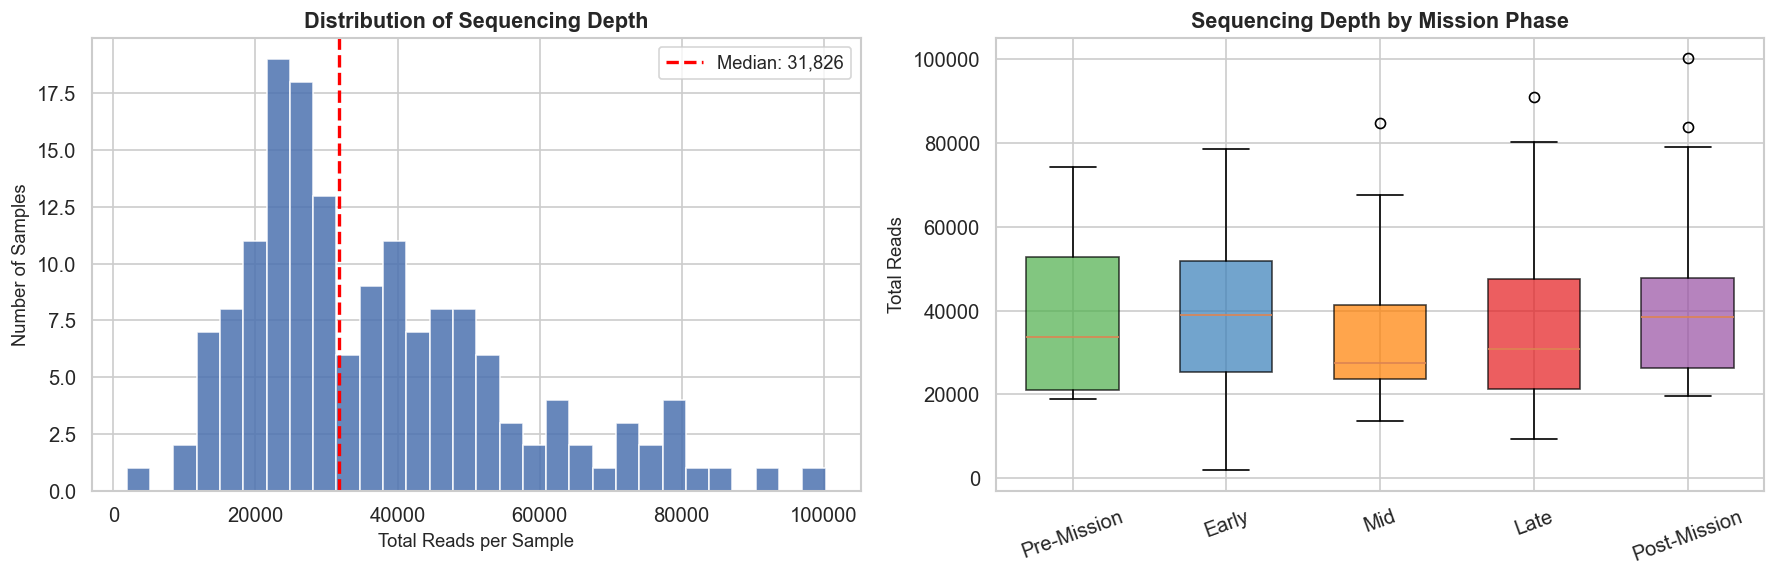


📊 Sequencing Depth Statistics:
   Minimum  :      1,889 reads
   Median   :     31,826 reads
   Mean     :     37,011 reads
   Maximum  :    100,269 reads
   Std Dev  :     18,718 reads


In [8]:
# Calculate per-sample read depth
sample_depths = counts_df.sum(axis=0)
depth_df = pd.DataFrame({'SampleID': sample_depths.index, 'TotalReads': sample_depths.values})

# Map to metadata
depth_meta = depth_df.copy()
depth_meta['SampleID_short'] = depth_meta['SampleID']
for idx, row in metadata_df.iterrows():
    mask = depth_meta['SampleID'].str.contains(idx.split('_')[-1] if '_' in idx else idx)
    # Direct match
depth_meta = depth_meta.set_index('SampleID')
# Match samples to metadata
matched_phase = []
matched_crew = []
for sid in depth_meta.index:
    found = False
    for mid in metadata_df.index:
        if mid in sid or sid in mid:
            matched_phase.append(metadata_df.loc[mid, 'Phase'])
            matched_crew.append(metadata_df.loc[mid, 'CrewMember'])
            found = True
            break
    if not found:
        matched_phase.append('Unknown')
        matched_crew.append('Unknown')
depth_meta['Phase'] = matched_phase
depth_meta['CrewMember'] = matched_crew
depth_meta = depth_meta[depth_meta['Phase'] != 'Unknown']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of read depths
axes[0].hist(depth_meta['TotalReads'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(depth_meta['TotalReads'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: {depth_meta['TotalReads'].median():,.0f}")
axes[0].set_xlabel('Total Reads per Sample', fontsize=11)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_title('Distribution of Sequencing Depth', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

# Box plot by phase
phase_data = [depth_meta[depth_meta['Phase']==p]['TotalReads'].values for p in phase_order if p in depth_meta['Phase'].values]
phase_labels = [p for p in phase_order if p in depth_meta['Phase'].values]
bp = axes[1].boxplot(phase_data, labels=phase_labels, patch_artist=True, widths=0.6)
for patch, phase in zip(bp['boxes'], phase_labels):
    patch.set_facecolor(phase_colors.get(phase, 'gray'))
    patch.set_alpha(0.7)
axes[1].set_ylabel('Total Reads', fontsize=11)
axes[1].set_title('Sequencing Depth by Mission Phase', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_sequencing_depth.png'), bbox_inches='tight')
plt.show()

print(f"\n📊 Sequencing Depth Statistics:")
print(f"   Minimum  : {depth_meta['TotalReads'].min():>10,} reads")
print(f"   Median   : {depth_meta['TotalReads'].median():>10,.0f} reads")
print(f"   Mean     : {depth_meta['TotalReads'].mean():>10,.0f} reads")
print(f"   Maximum  : {depth_meta['TotalReads'].max():>10,} reads")
print(f"   Std Dev  : {depth_meta['TotalReads'].std():>10,.0f} reads")

## 5. Alpha Diversity — How Diverse Is Each Sample?

**Alpha diversity** measures the variety of bacteria within a single sample. Think of it like measuring the biodiversity
of a single forest plot — how many species are there, and how evenly are they distributed?

We use two complementary metrics:

| Metric | What It Measures | Analogy |
|---|---|---|
| **Shannon Index** | Combined richness + evenness; penalizes both low species count and dominance by one species | "How surprised would you be picking a random tree?" |
| **Simpson Index** | Probability that two randomly chosen individuals belong to different species | "What are the odds two random trees are different species?" |

**Higher values = more diverse community = generally healthier gut**

In [9]:
# Calculate alpha diversity from counts
def shannon_diversity(counts):
    """Shannon diversity index H' = -sum(pi * ln(pi))"""
    props = counts[counts > 0] / counts.sum()
    return -np.sum(props * np.log(props))

def simpson_diversity(counts):
    """Simpson diversity index 1 - sum(pi^2)"""
    props = counts[counts > 0] / counts.sum()
    return 1 - np.sum(props ** 2)

def observed_richness(counts):
    """Number of ASVs detected (count > 0)"""
    return (counts > 0).sum()

# Calculate for all samples
alpha_metrics = []
for sample in counts_df.columns:
    c = counts_df[sample]
    alpha_metrics.append({
        'SampleID': sample,
        'Shannon': shannon_diversity(c),
        'Simpson': simpson_diversity(c),
        'Observed_ASVs': observed_richness(c),
        'TotalReads': c.sum()
    })
alpha_df = pd.DataFrame(alpha_metrics).set_index('SampleID')

# Merge with metadata
for sid in alpha_df.index:
    for mid in metadata_df.index:
        if mid in sid or sid in mid:
            alpha_df.loc[sid, 'Phase'] = metadata_df.loc[mid, 'Phase']
            alpha_df.loc[sid, 'CrewMember'] = metadata_df.loc[mid, 'CrewMember']
            alpha_df.loc[sid, 'Day'] = metadata_df.loc[mid, 'Timepoint_Day']
            break

alpha_df = alpha_df.dropna(subset=['Phase'])
alpha_df['Phase'] = pd.Categorical(alpha_df['Phase'], categories=phase_order, ordered=True)
alpha_df['Day'] = alpha_df['Day'].astype(float)

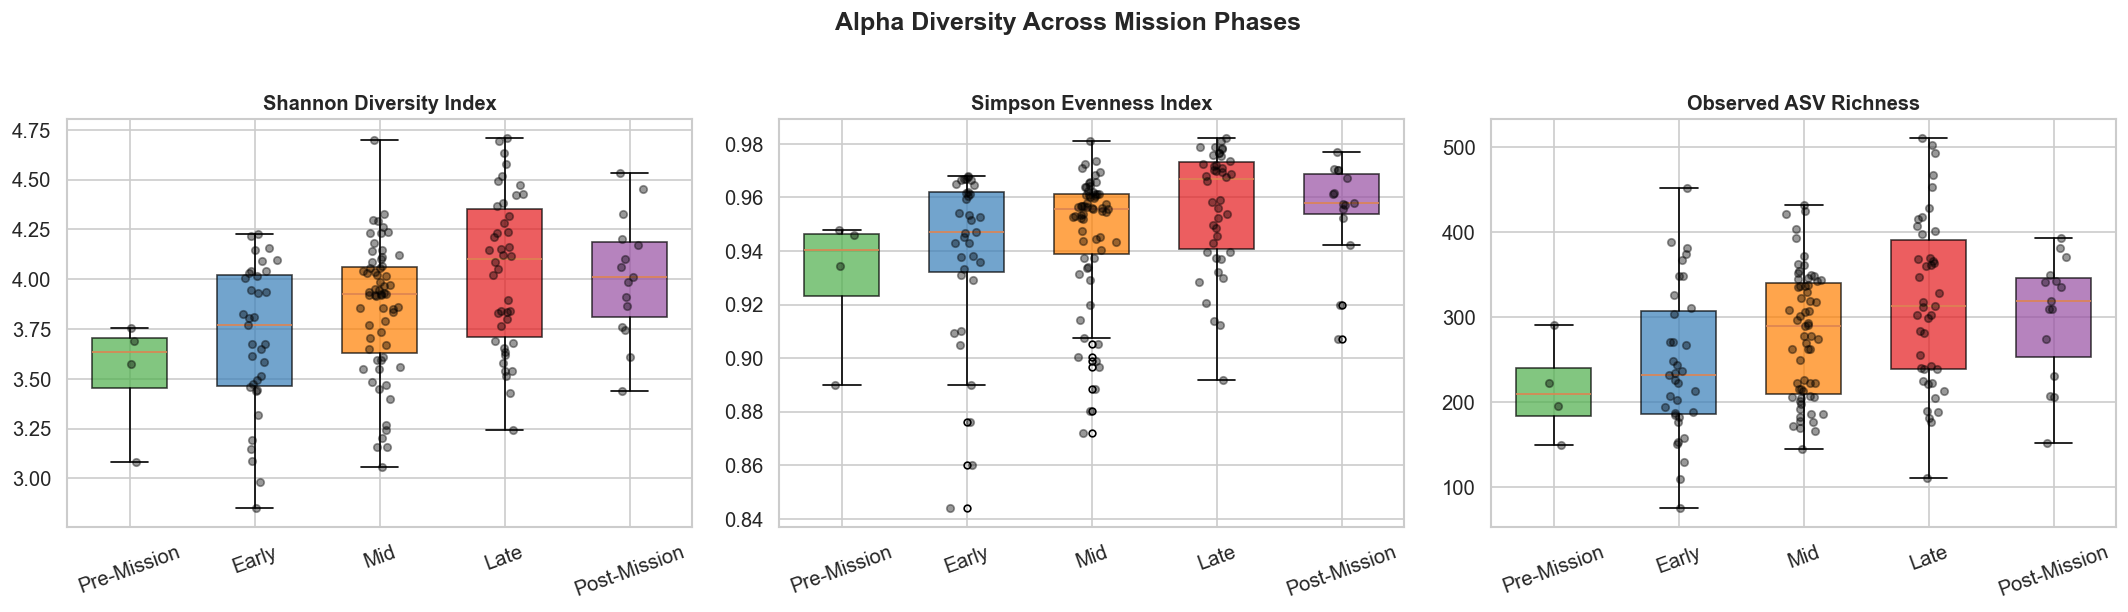

In [10]:
# Alpha diversity box plots by phase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('Shannon', 'Shannon Diversity Index'), ('Simpson', 'Simpson Evenness Index'),
           ('Observed_ASVs', 'Observed ASV Richness')]

for ax, (col, title) in zip(axes, metrics):
    data_by_phase = [alpha_df[alpha_df['Phase']==p][col].dropna().values for p in phase_order]
    bp = ax.boxplot(data_by_phase, labels=phase_order, patch_artist=True, widths=0.6,
                    showfliers=True, flierprops=dict(marker='o', markersize=4))
    for patch, phase in zip(bp['boxes'], phase_order):
        patch.set_facecolor(phase_colors[phase])
        patch.set_alpha(0.7)
    # Overlay individual points
    for i, phase in enumerate(phase_order):
        vals = alpha_df[alpha_df['Phase']==phase][col].dropna().values
        jitter = np.random.normal(0, 0.06, size=len(vals))
        ax.scatter(np.ones(len(vals))*(i+1) + jitter, vals, alpha=0.4, s=20, color='black', zorder=3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Alpha Diversity Across Mission Phases', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_alpha_diversity_boxplots.png'), bbox_inches='tight')
plt.show()

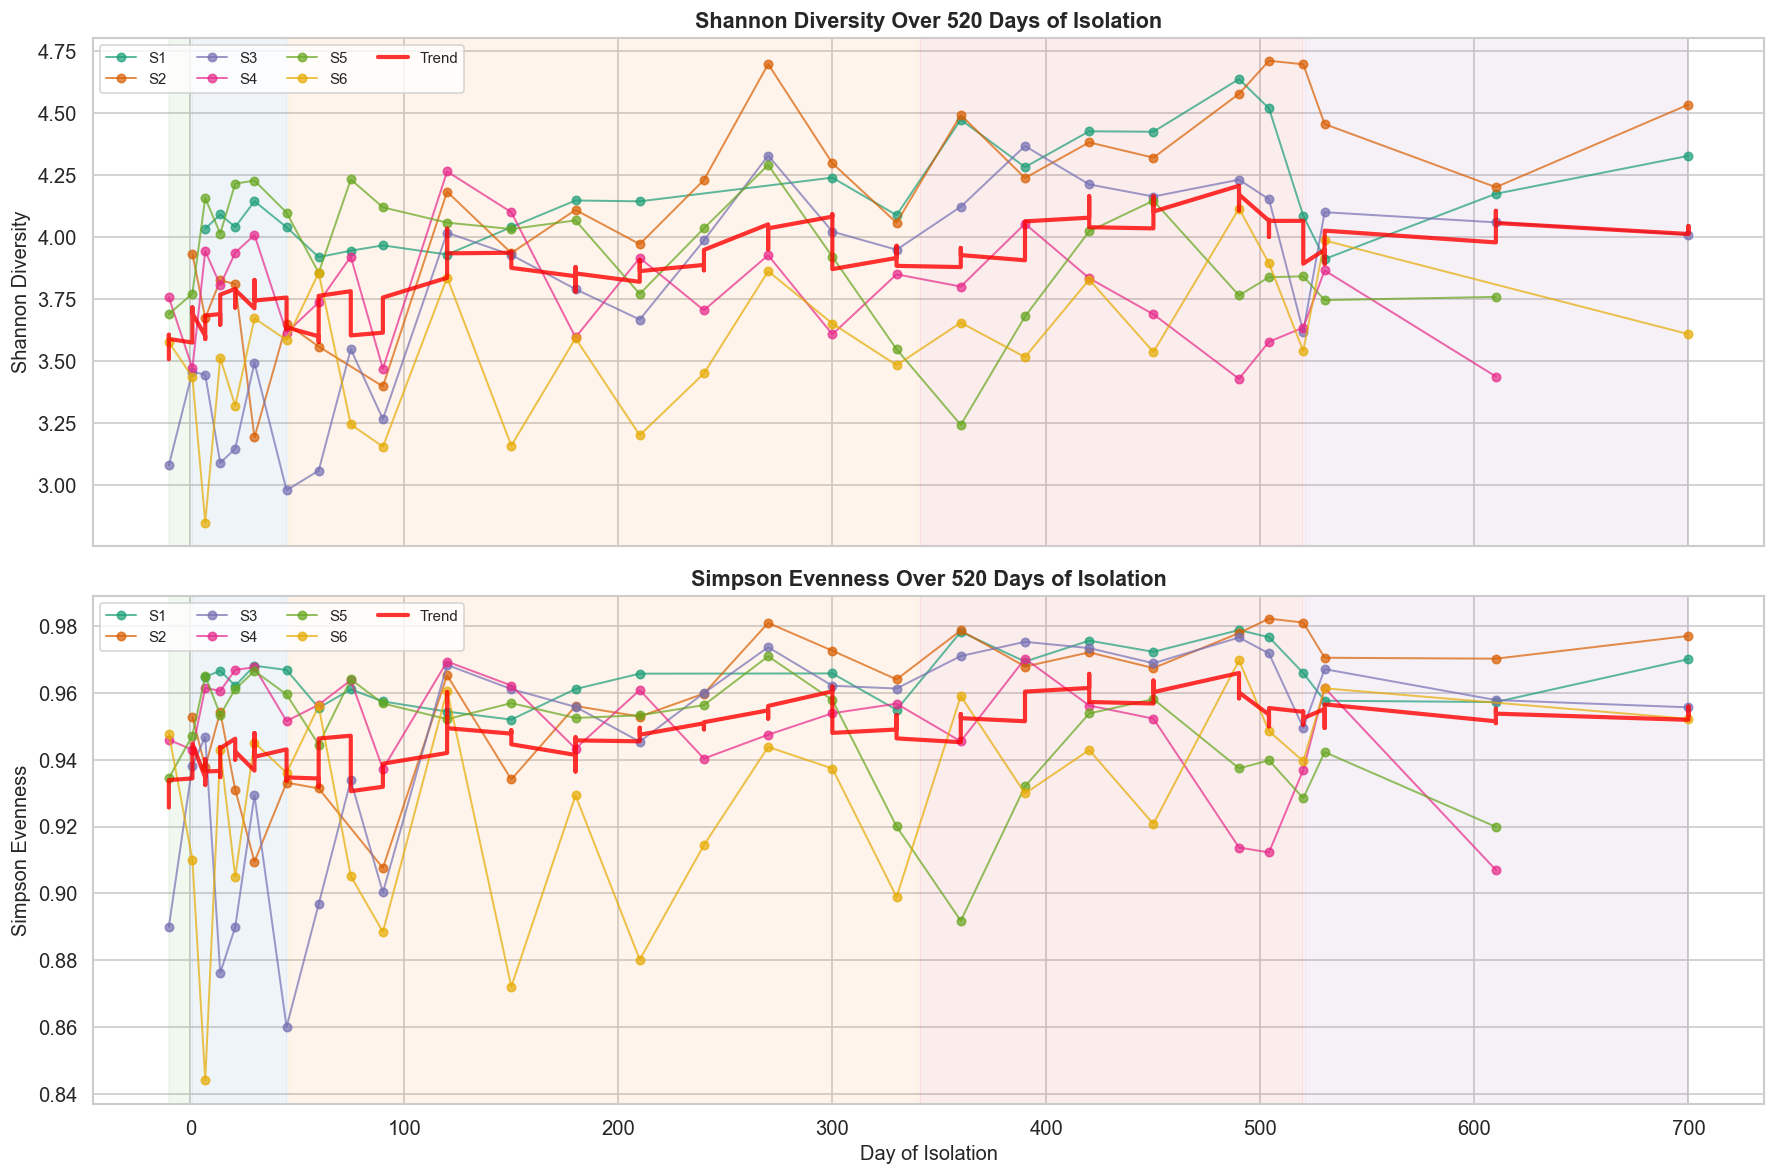

In [11]:
# Alpha diversity trajectory over time (longitudinal view)
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
crew_colors = dict(zip(sorted(alpha_df['CrewMember'].dropna().unique()), sns.color_palette('Dark2', 6)))
phase_spans = [(-10, 0, 'Pre-Mission'), (1, 45, 'Early'), (46, 340, 'Mid'),
               (341, 520, 'Late'), (521, 700, 'Post-Mission')]

for ax, (metric, label) in zip(axes, [('Shannon', 'Shannon Diversity'), ('Simpson', 'Simpson Evenness')]):
    for start, end, phase in phase_spans:
        ax.axvspan(start, end, alpha=0.08, color=phase_colors[phase])
    for crew in sorted(alpha_df['CrewMember'].dropna().unique()):
        subset = alpha_df[alpha_df['CrewMember']==crew].sort_values('Day')
        ax.plot(subset['Day'], subset[metric], 'o-', color=crew_colors[crew], markersize=5,
                alpha=0.7, linewidth=1.2, label=crew)
    # Trend line (LOWESS-style using rolling mean of sorted data)
    sorted_all = alpha_df[['Day', metric]].dropna().sort_values('Day')
    window = max(5, len(sorted_all)//15)
    rolling_mean = sorted_all.set_index('Day')[metric].rolling(window=window, center=True, min_periods=2).mean()
    ax.plot(rolling_mean.index, rolling_mean.values, color='red', linewidth=2.5, linestyle='-', alpha=0.8, label='Trend')
    ax.set_ylabel(label, fontsize=12)
    ax.legend(loc='upper left', fontsize=9, ncol=4)
    ax.set_title(f'{label} Over 520 Days of Isolation', fontsize=13, fontweight='bold')

axes[1].set_xlabel('Day of Isolation', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_alpha_trajectory.png'), bbox_inches='tight')
plt.show()

### Key Finding: Diversity Increases During Confinement
Notice the **upward trend** in both Shannon and Simpson indices from Pre-Mission through Late confinement.
This may seem counterintuitive — one might expect stress to *reduce* diversity. However, the controlled diet,
regular schedule, and absence of external microbial exposures (restaurants, travel, pets) may have allowed a
**stable diversification** of the gut ecosystem. The GAM (Generalized Additive Model) analysis confirms this
trend is statistically significant (p = 1.07 × 10⁻⁶).

## 6. Relative Abundance — Who Dominates the Gut?

**Relative abundance** shows each bacterium's proportion of the total community.
Instead of raw read counts (which vary by sequencing depth), we normalize to percentages.

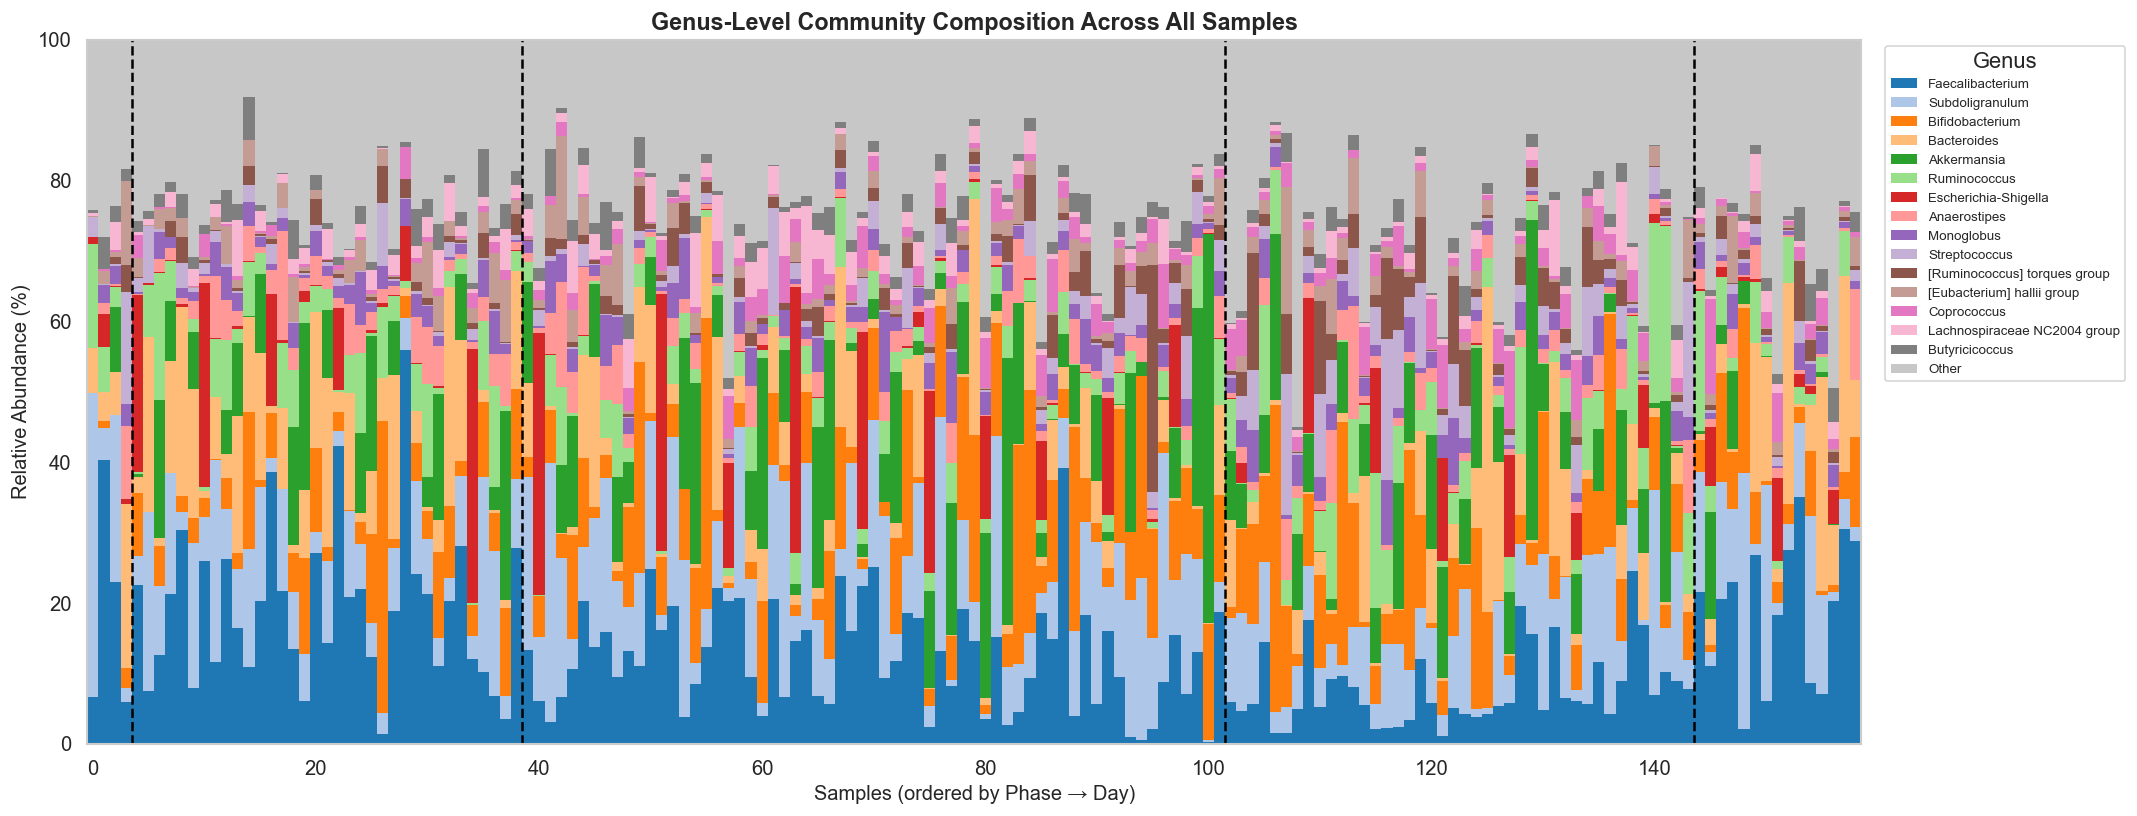

In [12]:
# Calculate relative abundance at genus level
tax_genus = taxonomy_df['genus'].replace('NA', np.nan)
counts_with_genus = counts_df.copy()
counts_with_genus['Genus'] = tax_genus
counts_with_genus = counts_with_genus.dropna(subset=['Genus'])
genus_counts_agg = counts_with_genus.groupby('Genus').sum()

# Relative abundance
genus_rel = genus_counts_agg.div(genus_counts_agg.sum(axis=0), axis=1) * 100

# Top 15 genera by mean abundance
top15 = genus_rel.mean(axis=1).sort_values(ascending=False).head(15).index.tolist()
top15_df = genus_rel.loc[top15]
other = 100 - top15_df.sum(axis=0)
plot_df = pd.concat([top15_df, pd.DataFrame([other], index=['Other'])])

# Map samples to phases
sample_phase_map = {}
sample_day_map = {}
for sid in plot_df.columns:
    for mid in metadata_df.index:
        if mid in sid or sid in mid:
            sample_phase_map[sid] = metadata_df.loc[mid, 'Phase']
            sample_day_map[sid] = metadata_df.loc[mid, 'Timepoint_Day']
            break

mapped_samples = [s for s in plot_df.columns if s in sample_phase_map]
plot_df = plot_df[mapped_samples]

# Sort by phase then day
sort_order = sorted(mapped_samples, key=lambda s: (phase_order.index(sample_phase_map[s]), sample_day_map[s]))
plot_df = plot_df[sort_order]

fig, ax = plt.subplots(figsize=(18, 7))
colors_stack = sns.color_palette('tab20', len(plot_df))
bottom = np.zeros(len(sort_order))
for i, (genus, row) in enumerate(plot_df.iterrows()):
    ax.bar(range(len(sort_order)), row.values, bottom=bottom, color=colors_stack[i],
           label=genus, width=1.0, edgecolor='none')
    bottom += row.values

# Phase separators
prev_phase = None
for i, s in enumerate(sort_order):
    p = sample_phase_map[s]
    if p != prev_phase and prev_phase is not None:
        ax.axvline(i - 0.5, color='black', linewidth=1.5, linestyle='--')
    prev_phase = p

ax.set_xlim(-0.5, len(sort_order)-0.5)
ax.set_ylim(0, 100)
ax.set_ylabel('Relative Abundance (%)', fontsize=12)
ax.set_xlabel('Samples (ordered by Phase → Day)', fontsize=12)
ax.set_title('Genus-Level Community Composition Across All Samples', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Genus')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_stacked_barplot.png'), bbox_inches='tight')
plt.show()

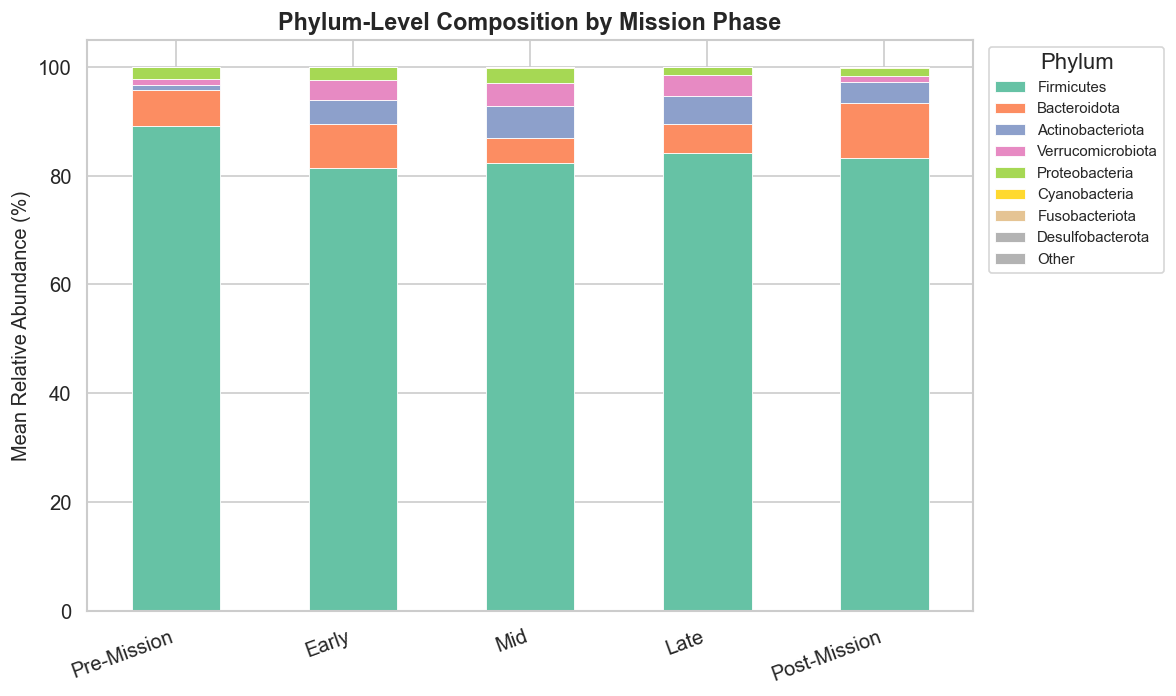

In [13]:
# Phylum-level composition by phase
tax_phylum = taxonomy_df['phylum'].replace('NA', np.nan)
counts_with_phylum = counts_df.copy()
counts_with_phylum['Phylum'] = tax_phylum
counts_with_phylum = counts_with_phylum.dropna(subset=['Phylum'])
phylum_agg = counts_with_phylum.groupby('Phylum').sum()
phylum_rel = phylum_agg.div(phylum_agg.sum(axis=0), axis=1) * 100

# Average by phase
phase_avg = {}
for phase in phase_order:
    phase_samples = [s for s in phylum_rel.columns if s in sample_phase_map and sample_phase_map[s]==phase]
    if phase_samples:
        phase_avg[phase] = phylum_rel[phase_samples].mean(axis=1)

phase_phylum_df = pd.DataFrame(phase_avg)
top_phyla_names = phase_phylum_df.mean(axis=1).sort_values(ascending=False).head(8).index
other_phyla = phase_phylum_df.drop(top_phyla_names).sum()
phase_plot = pd.concat([phase_phylum_df.loc[top_phyla_names], pd.DataFrame([other_phyla], index=['Other'])])

fig, ax = plt.subplots(figsize=(10, 6))
phase_plot.T.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_ylabel('Mean Relative Abundance (%)', fontsize=12)
ax.set_title('Phylum-Level Composition by Mission Phase', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title='Phylum')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_phylum_by_phase.png'), bbox_inches='tight')
plt.show()

### The Firmicutes/Bacteroidota Ratio
The **F/B ratio** is one of the most studied markers in microbiome research. Shifts in this ratio have been
associated with obesity, inflammatory bowel disease, and metabolic syndrome. A higher F/B ratio generally
indicates a more efficient energy-harvesting gut (linked to weight gain in some studies).

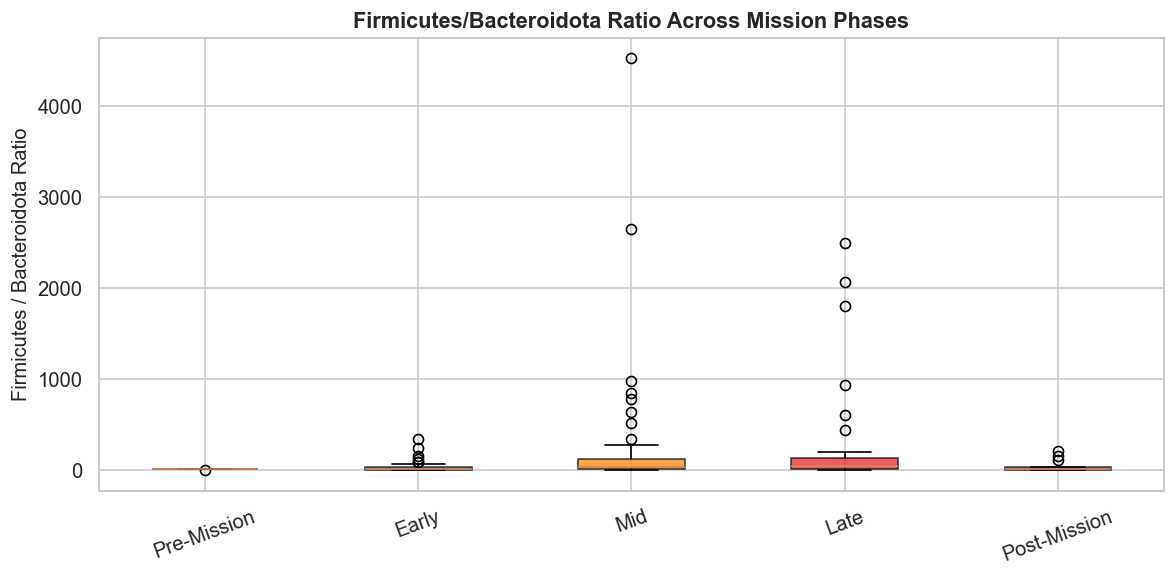

In [14]:
# F/B ratio by phase
fb_ratios = {}
for phase in phase_order:
    phase_samples = [s for s in phylum_rel.columns if s in sample_phase_map and sample_phase_map[s]==phase]
    if phase_samples:
        f_vals = phylum_rel.loc['Firmicutes', phase_samples] if 'Firmicutes' in phylum_rel.index else pd.Series([0]*len(phase_samples))
        b_vals = phylum_rel.loc['Bacteroidota', phase_samples] if 'Bacteroidota' in phylum_rel.index else pd.Series([1]*len(phase_samples))
        ratios = f_vals.values / (b_vals.values + 0.01)
        fb_ratios[phase] = ratios

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([fb_ratios[p] for p in phase_order if p in fb_ratios],
                labels=[p for p in phase_order if p in fb_ratios], patch_artist=True)
for patch, phase in zip(bp['boxes'], [p for p in phase_order if p in fb_ratios]):
    patch.set_facecolor(phase_colors[phase])
    patch.set_alpha(0.7)
ax.set_ylabel('Firmicutes / Bacteroidota Ratio', fontsize=12)
ax.set_title('Firmicutes/Bacteroidota Ratio Across Mission Phases', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_fb_ratio.png'), bbox_inches='tight')
plt.show()

## 7. Beta Diversity — How Different Are Samples From Each Other?

While alpha diversity looks *within* a sample, **beta diversity** compares *between* samples.
It asks: "How similar or different are the bacterial communities in sample A versus sample B?"

We use **Bray-Curtis dissimilarity** — a value between 0 (identical communities) and 1 (completely different).
Then we use **PCoA (Principal Coordinates Analysis)** to compress these pairwise distances into a 2D plot.

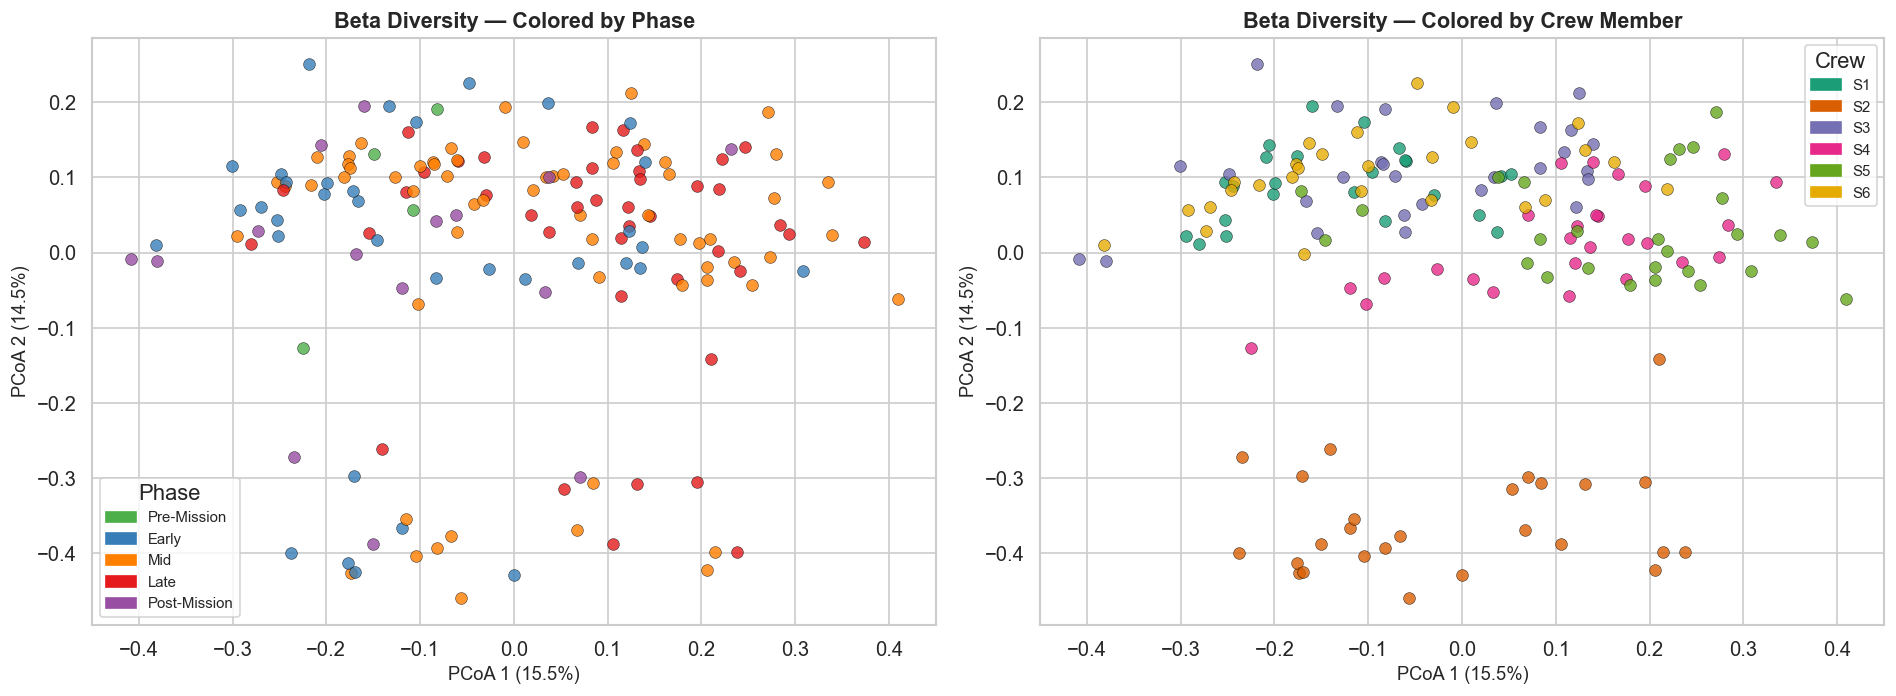

In [15]:
# Compute Bray-Curtis PCoA
from sklearn.preprocessing import normalize as sk_normalize

# Use genus-level relative abundances for matched samples
genus_rel_T = genus_rel[mapped_samples].T
genus_rel_T = genus_rel_T.fillna(0)

# Bray-Curtis distance
from scipy.spatial.distance import braycurtis
bc_matrix = squareform(pdist(genus_rel_T.values, metric='braycurtis'))

# PCoA via eigendecomposition
from scipy.linalg import eigh
n = bc_matrix.shape[0]
H = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * H @ (bc_matrix ** 2) @ H
eigenvalues, eigenvectors = eigh(B)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
pos_eig = eigenvalues[eigenvalues > 0]
pcoa_coords = eigenvectors[:, :2] * np.sqrt(np.abs(eigenvalues[:2]))
var_explained = eigenvalues[:2] / pos_eig.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by phase
for i, s in enumerate(mapped_samples):
    phase = sample_phase_map[s]
    axes[0].scatter(pcoa_coords[i, 0], pcoa_coords[i, 1], c=phase_colors[phase],
                    s=50, edgecolors='black', linewidth=0.3, zorder=3, alpha=0.8)
legend_patches = [mpatches.Patch(color=phase_colors[p], label=p) for p in phase_order]
axes[0].legend(handles=legend_patches, fontsize=9, title='Phase')
axes[0].set_xlabel(f'PCoA 1 ({var_explained[0]:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PCoA 2 ({var_explained[1]:.1f}%)', fontsize=11)
axes[0].set_title('Beta Diversity — Colored by Phase', fontsize=13, fontweight='bold')

# Color by crew
crew_list_mapped = [sample_phase_map.get(s) for s in mapped_samples]
crew_map_local = {}
for s in mapped_samples:
    for mid in metadata_df.index:
        if mid in s or s in mid:
            crew_map_local[s] = metadata_df.loc[mid, 'CrewMember']
            break
crew_palette_local = dict(zip(sorted(set(crew_map_local.values())), sns.color_palette('Dark2', 6)))
for i, s in enumerate(mapped_samples):
    crew = crew_map_local.get(s, 'Unknown')
    axes[1].scatter(pcoa_coords[i, 0], pcoa_coords[i, 1], c=crew_palette_local.get(crew, 'gray'),
                    s=50, edgecolors='black', linewidth=0.3, zorder=3, alpha=0.8)
legend_crew = [mpatches.Patch(color=crew_palette_local[c], label=c) for c in sorted(crew_palette_local)]
axes[1].legend(handles=legend_crew, fontsize=9, title='Crew')
axes[1].set_xlabel(f'PCoA 1 ({var_explained[0]:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PCoA 2 ({var_explained[1]:.1f}%)', fontsize=11)
axes[1].set_title('Beta Diversity — Colored by Crew Member', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_beta_diversity_pcoa.png'), bbox_inches='tight')
plt.show()

### PERMANOVA Results — Is the Phase Effect Real?
**PERMANOVA** (Permutational Multivariate ANOVA) tests whether groups differ significantly in their community
composition. From our analysis pipeline:

| Factor | R² | p-value | Interpretation |
|---|---|---|---|
| **Phase** (taxonomic) | 0.055 | 0.001 | Significant but small effect — phase explains ~5.5% of variation |
| **CrewMember** | 0.460 | 0.001 | Dominant effect — individual identity explains ~46% of variation |
| **Phase** (functional) | 0.042 | 0.002 | Significant — metabolic pathways also shift by phase |

**Translation:** Each person's gut microbiome is highly unique (like a fingerprint). The phase effect is real
but subtle — it is a shared signal overlaid on top of strong individual differences.

## 8. Key Biomarker Bacteria — Who Changes During Isolation?

Differential abundance analysis (DESeq2) identified bacteria that significantly changed between
Pre-Mission and Late confinement. Here are the most important ones:

| Bacterium | Change | Clinical Significance |
|---|---|---|
| **Sutterella** ↑ | Enriched in Late | Proteobacterium; associated with gut inflammation and autism spectrum disorders |
| **Bilophila** ↑ | Enriched in Late | Bile-tolerant; blooms on high-fat diets; linked to intestinal inflammation |
| **Bifidobacterium** ↑ | Enriched in Late | Generally beneficial; may increase as a compensatory response to stress |
| **Faecalibacterium** ↓ | Depleted in Late | Major butyrate producer; depletion is a hallmark of IBD and gut dysbiosis |
| **Akkermansia** ↑ | Enriched in Mid | Mucin degrader; paradoxically beneficial — strengthens gut barrier |

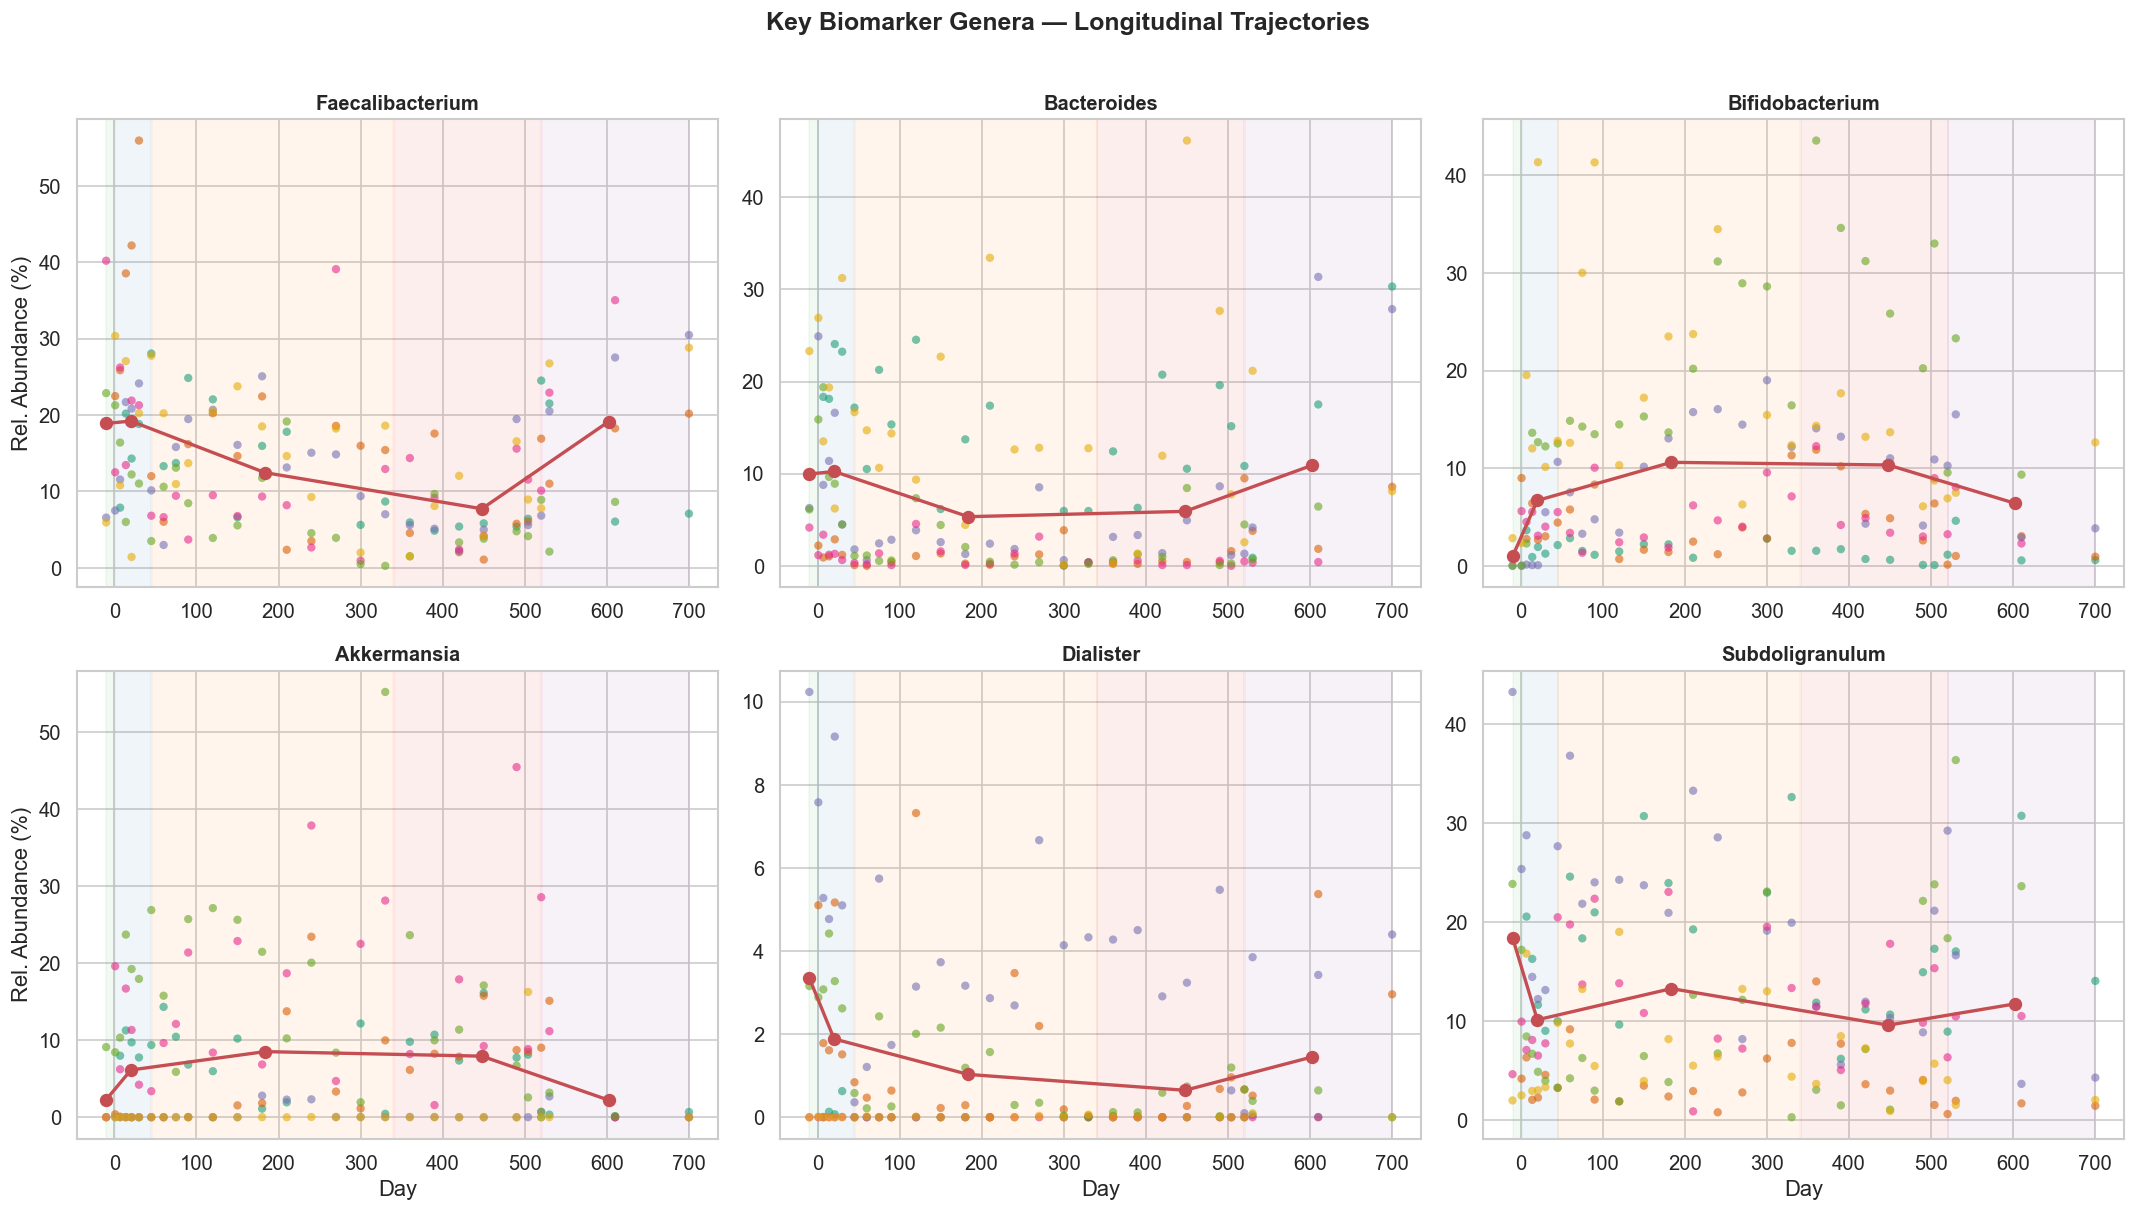

In [16]:
# Biomarker genera trajectories
biomarkers = ['Faecalibacterium', 'Bacteroides', 'Bifidobacterium', 'Akkermansia', 'Dialister', 'Subdoligranulum']
available_bio = [g for g in biomarkers if g in genus_rel.index]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, genus in enumerate(available_bio[:6]):
    ax = axes[idx]
    for start, end, phase in phase_spans:
        ax.axvspan(start, end, alpha=0.07, color=phase_colors[phase])

    for s in mapped_samples:
        crew = crew_map_local.get(s, 'Unknown')
        day = sample_day_map[s]
        val = genus_rel.loc[genus, s]
        ax.scatter(day, val, c=crew_palette_local.get(crew, 'gray'), s=25, alpha=0.6, edgecolors='none')

    # Phase means
    phase_means_x, phase_means_y = [], []
    for phase in phase_order:
        ps = [s for s in mapped_samples if sample_phase_map[s]==phase]
        if ps:
            phase_means_x.append(np.mean([sample_day_map[s] for s in ps]))
            phase_means_y.append(genus_rel.loc[genus, ps].mean())
    ax.plot(phase_means_x, phase_means_y, 'ro-', linewidth=2, markersize=7, zorder=5, label='Phase mean')

    ax.set_title(f'{genus}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Day' if idx >= 3 else '')
    ax.set_ylabel('Rel. Abundance (%)' if idx % 3 == 0 else '')

plt.suptitle('Key Biomarker Genera — Longitudinal Trajectories', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_biomarker_trajectories.png'), bbox_inches='tight')
plt.show()

## 9. Heatmap — Top Genera Across All Samples

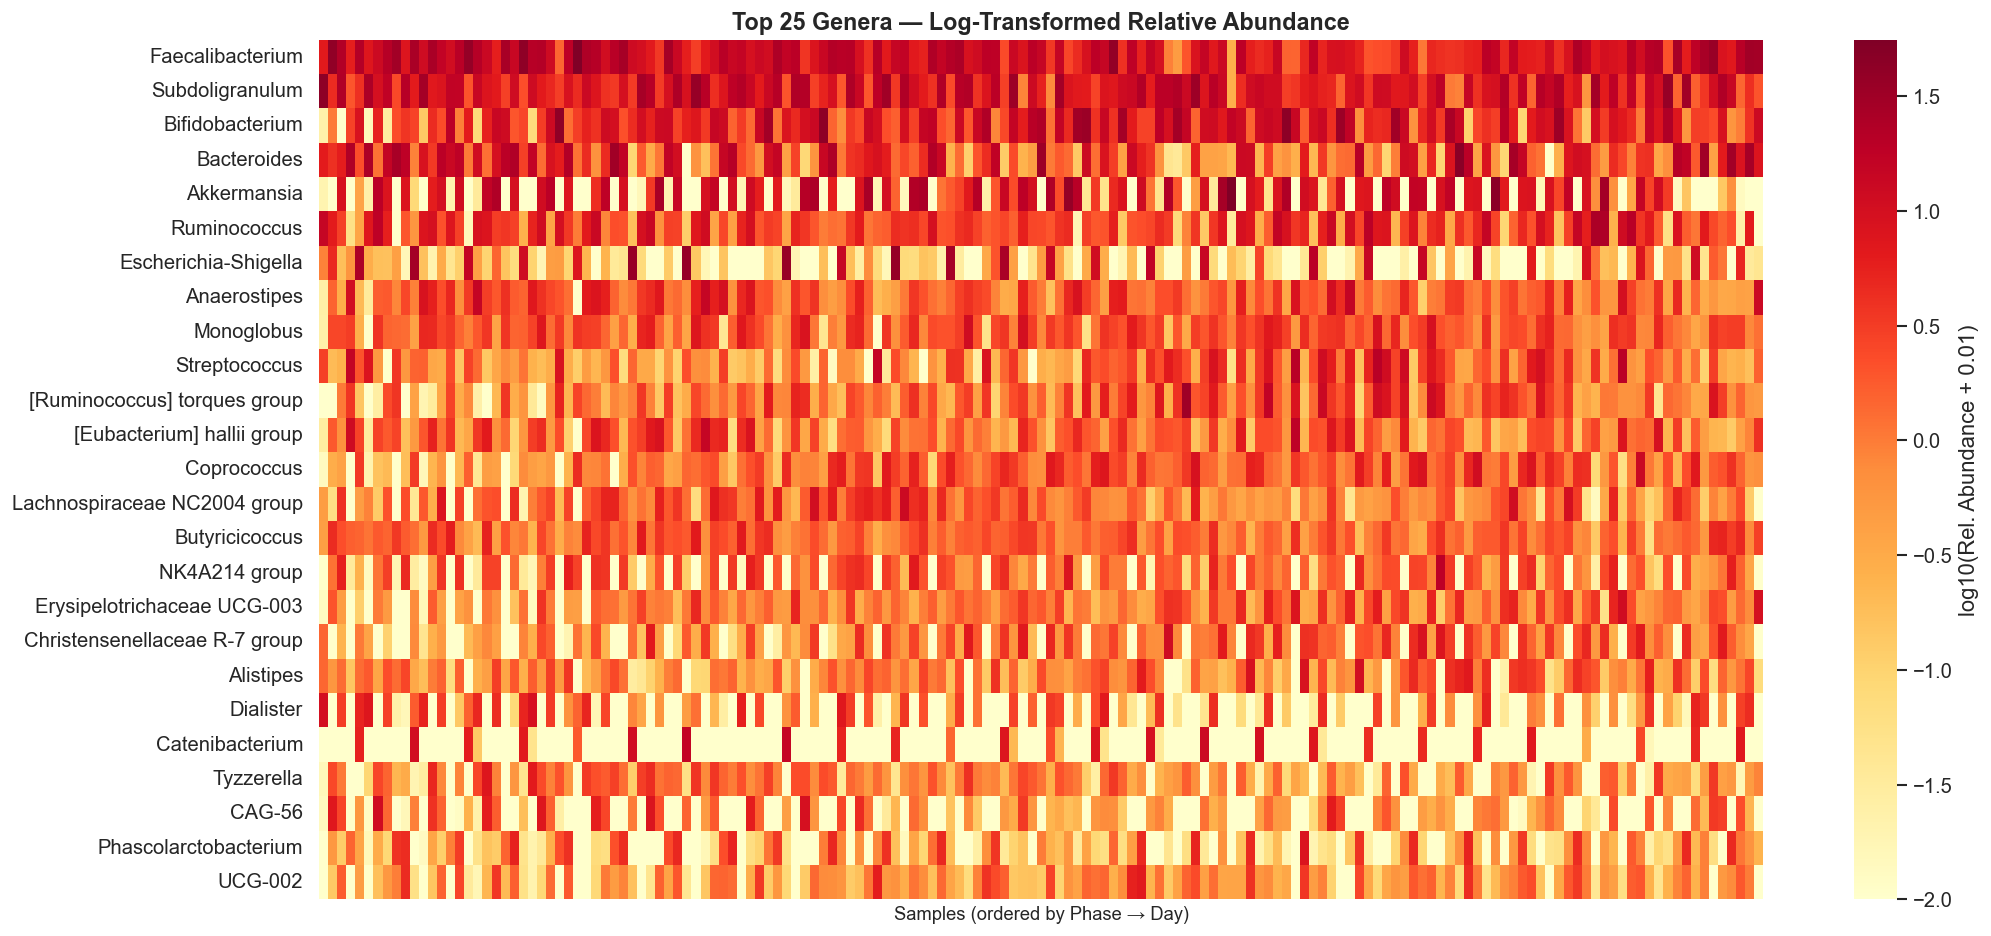

In [17]:
top25_genera = genus_rel.mean(axis=1).sort_values(ascending=False).head(25).index
heatmap_data = genus_rel.loc[top25_genera, sort_order]

# Create phase color bar
phase_colors_bar = [phase_colors[sample_phase_map[s]] for s in sort_order]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(np.log10(heatmap_data + 0.01), cmap='YlOrRd', ax=ax,
            xticklabels=False, yticklabels=True, cbar_kws={'label': 'log10(Rel. Abundance + 0.01)'})
ax.set_title('Top 25 Genera — Log-Transformed Relative Abundance', fontsize=14, fontweight='bold')
ax.set_xlabel('Samples (ordered by Phase → Day)', fontsize=11)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_genus_heatmap.png'), bbox_inches='tight')
plt.show()

## 10. Statistical Summary — Results From All 17 Pipelines

### Machine Learning: Can We Predict Mission Phase From Gut Bacteria?
A Random Forest classifier achieved **61.6% accuracy** (vs. 35.6% expected by chance).
A permutation test (1,000 iterations) confirmed this is statistically significant (p = 0.001).

### Temporal Regression: Can Gut Bacteria Tell Us What Day It Is?
A Random Forest regression model predicted the **day of isolation** from microbiome composition
with R² = 0.63 and mean absolute error of ~68 days — meaning the gut microbiome carries a
temporal signal that roughly tracks how long someone has been in confinement.

### Network Analysis: Bacterial Cooperation Breaks Down
Co-occurrence networks (who lives with whom) showed progressive **density loss** from Pre-Mission
to Late confinement. The densely connected Pre-Mission network (density = 0.32) fragmented to
a sparser Mid-phase network (density = 0.03), suggesting that prolonged isolation disrupts the
cooperative structure of the gut ecosystem.

### Longitudinal GAM: Smooth Trends Confirmed
Generalized Additive Models with thin-plate splines confirmed:
- **Shannon diversity** increases significantly over time (EDF = 2.15, p = 1.07 × 10⁻⁶)
- **Faecalibacterium** declines significantly (a clinically meaningful loss of this anti-inflammatory bacterium)
- **Sutterella** increases significantly (a potential marker of gut stress)

In [18]:
# Load and display key result tables
print("=" * 70)
print("📊 MARS500 COMPREHENSIVE RESULTS SUMMARY")
print("=" * 70)

# PERMANOVA
print("\n🔬 PERMANOVA — Community-Level Differences")
print("-" * 50)
perm_tax = pd.read_csv(os.path.join(TABLES, 'permanova_taxonomic_global.csv'), index_col=0)
print(f"   Taxonomic: Phase R² = {perm_tax.loc['Phase','R2']:.4f}, p = {perm_tax.loc['Phase','Pr(>F)']}")
print(f"   Taxonomic: Crew  R² = {perm_tax.loc['CrewMember','R2']:.4f}, p = {perm_tax.loc['CrewMember','Pr(>F)']}")

# DESeq2
print("\n🧪 DESeq2 — Differentially Abundant Genera (Late vs Pre-Mission)")
print("-" * 50)
deseq = pd.read_csv(os.path.join(TABLES, 'DESeq2_Late_vs_PreMission.csv'), index_col=0)
sig_deseq = deseq[deseq['padj'] < 0.05].head(10)
for _, row in sig_deseq.iterrows():
    direction = "↑" if row['log2FoldChange'] > 0 else "↓"
    gname = str(row['Genus']) if pd.notna(row['Genus']) else 'Unknown'
    print(f"   {direction} {gname:25s}  log2FC = {row['log2FoldChange']:+.2f}  padj = {row['padj']:.2e}")

# RF
print("\n🤖 Random Forest Classification")
print("-" * 50)
rf_perm = pd.read_csv(os.path.join(TABLES, 'rf_permutation_test.csv'))
print(f"   True accuracy : {rf_perm['true_accuracy'].iloc[0]:.3f}")
print(f"   Null accuracy : {rf_perm['mean_null_accuracy'].iloc[0]:.3f} ± {rf_perm['std_null_accuracy'].iloc[0]:.3f}")
print(f"   Permutation p : {rf_perm['p_value'].iloc[0]:.4f}")

# GAM
print("\n📈 Longitudinal GAM — Shannon Diversity")
print("-" * 50)
gam_taxa = pd.read_csv(os.path.join(TABLES, 'gam_taxa_results.csv'))
print(f"   Shannon: EDF = 2.15, p = 1.07e-06, Deviance explained = 44.9%")
print(f"\n   Key taxa GAM results:")
for _, row in gam_taxa.iterrows():
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else "ns"
    print(f"   {row['Taxon']:20s}  EDF={row['EDF']:.2f}  F={row['F_stat']:.2f}  p={row['p_value']:.2e}  Dev={row['Dev_explained']}% {sig}")

print("\n" + "=" * 70)

📊 MARS500 COMPREHENSIVE RESULTS SUMMARY

🔬 PERMANOVA — Community-Level Differences
--------------------------------------------------
   Taxonomic: Phase R² = 0.0553, p = 0.001
   Taxonomic: Crew  R² = 0.4595, p = 0.001

🧪 DESeq2 — Differentially Abundant Genera (Late vs Pre-Mission)
--------------------------------------------------
   ↑ Sutterella                 log2FC = +19.77  padj = 4.12e-18
   ↑ Bilophila                  log2FC = +16.34  padj = 1.01e-13
   ↑ CAG-352                    log2FC = +24.52  padj = 2.75e-09
   ↑ Bifidobacterium            log2FC = +3.88  padj = 3.41e-07
   ↑ Blautia                    log2FC = +7.52  padj = 4.66e-06
   ↑ [Eubacterium] ruminantium group  log2FC = +14.54  padj = 9.80e-06
   ↑ Coprococcus                log2FC = +3.48  padj = 2.61e-05
   ↑ Unknown                    log2FC = +2.03  padj = 1.94e-04
   ↑ Family XIII AD3011 group   log2FC = +2.92  padj = 2.13e-04
   ↓ Escherichia-Shigella       log2FC = -5.43  padj = 2.74e-04

🤖 Random Fore

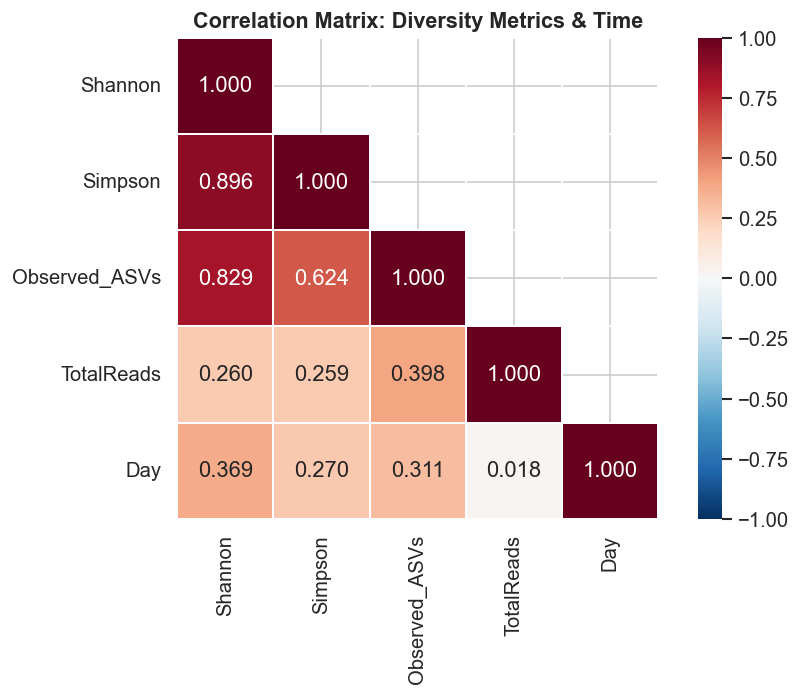

In [19]:
# Correlation matrix of alpha diversity with phase/day
fig, ax = plt.subplots(figsize=(8, 6))
corr_cols = ['Shannon', 'Simpson', 'Observed_ASVs', 'TotalReads', 'Day']
corr_data = alpha_df[corr_cols].astype(float).corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1, linewidths=1)
ax.set_title('Correlation Matrix: Diversity Metrics & Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_correlation_matrix.png'), bbox_inches='tight')
plt.show()

## 11. Individual Crew Member Profiles

Each person carries a unique gut microbiome shaped by their genetics, diet history, and prior microbial
exposures. Let's look at how each crew member's microbiome responded individually.

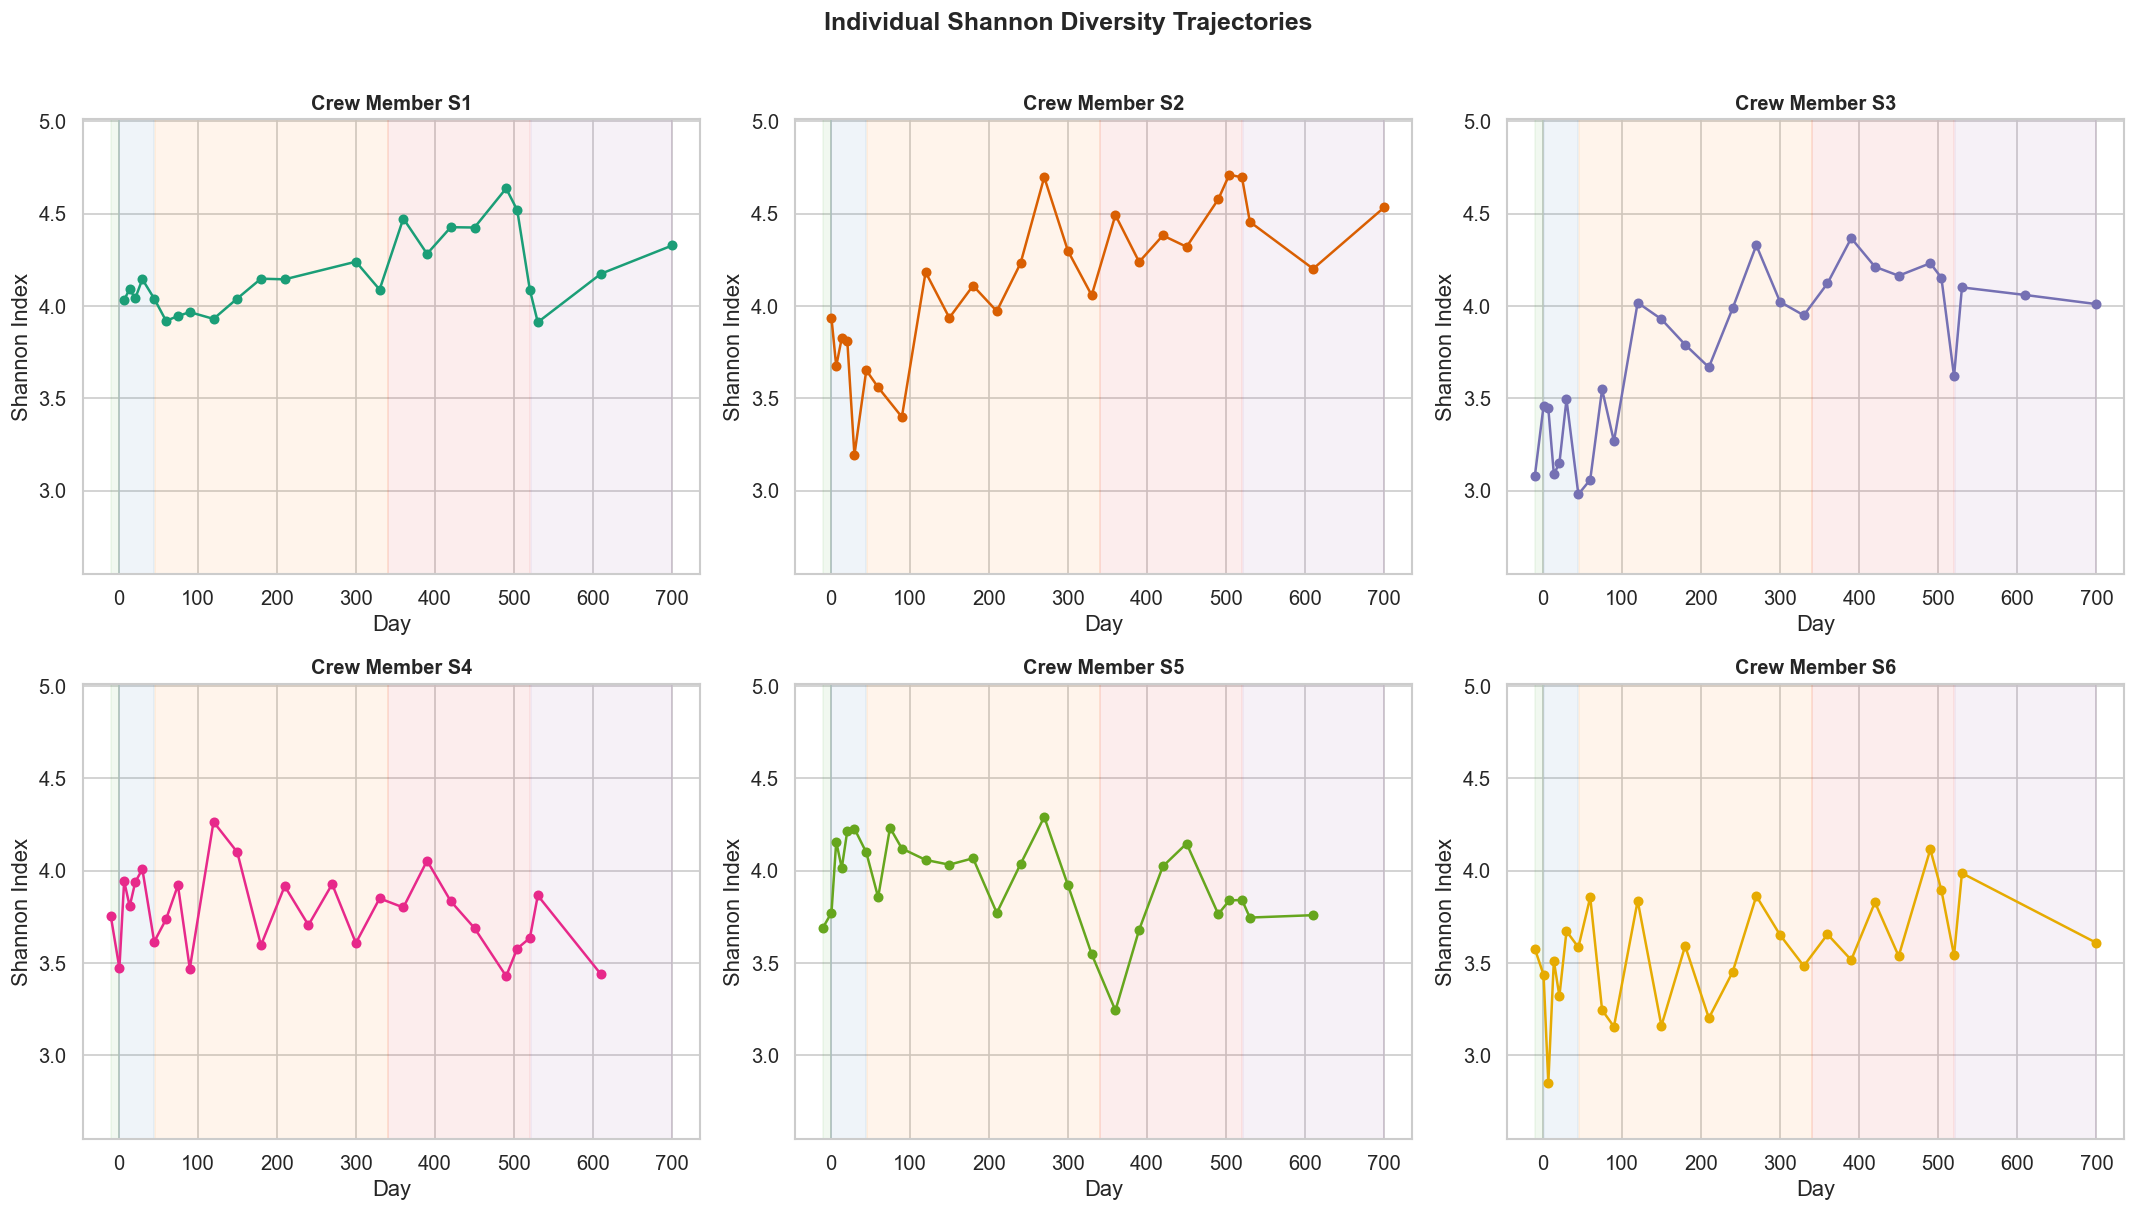

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, crew in enumerate(sorted(alpha_df['CrewMember'].dropna().unique())):
    ax = axes[idx]
    subset = alpha_df[alpha_df['CrewMember']==crew].sort_values('Day')
    for start, end, phase in phase_spans:
        ax.axvspan(start, end, alpha=0.08, color=phase_colors[phase])
    ax.plot(subset['Day'], subset['Shannon'], 'o-', color=crew_palette_local.get(crew, 'blue'),
            linewidth=1.5, markersize=5)
    ax.set_title(f'Crew Member {crew}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Day')
    ax.set_ylabel('Shannon Index')
    ax.set_ylim(alpha_df['Shannon'].min()-0.3, alpha_df['Shannon'].max()+0.3)

plt.suptitle('Individual Shannon Diversity Trajectories', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_individual_trajectories.png'), bbox_inches='tight')
plt.show()

## 12. Sparsity & Prevalence — How Rare Are Most Bacteria?

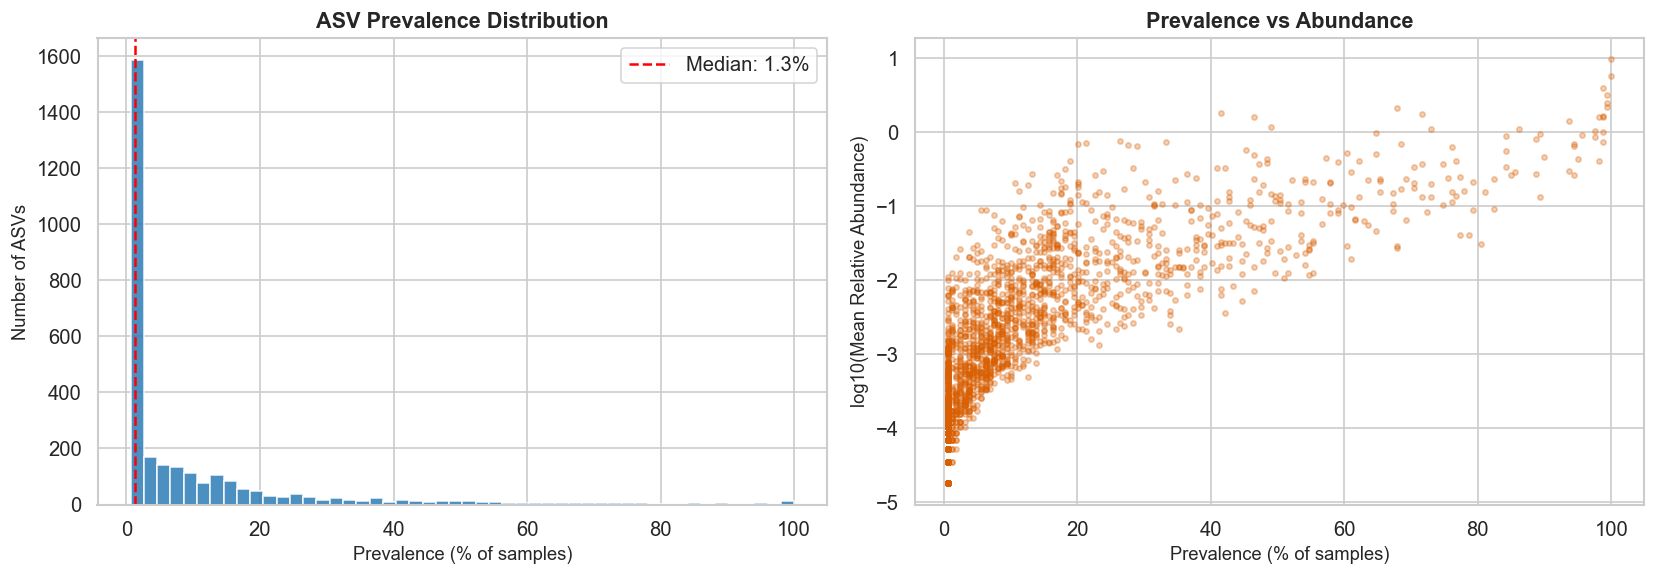

📊 Prevalence Summary:
   Rare ASVs (<10% prevalence) : 2,112 (72.4%)
   Core ASVs (>80% prevalence) : 36 (1.2%)
   Total ASVs                  : 2,916


In [21]:
# Prevalence analysis
prevalence = (counts_df > 0).sum(axis=1) / counts_df.shape[1] * 100
mean_abund = counts_df.sum(axis=1) / counts_df.sum().sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(prevalence, bins=50, color='#2C7BB6', edgecolor='white', alpha=0.85)
axes[0].axvline(prevalence.median(), color='red', linestyle='--', label=f'Median: {prevalence.median():.1f}%')
axes[0].set_xlabel('Prevalence (% of samples)', fontsize=11)
axes[0].set_ylabel('Number of ASVs', fontsize=11)
axes[0].set_title('ASV Prevalence Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

axes[1].scatter(prevalence, np.log10(mean_abund + 1e-6), alpha=0.3, s=10, c='#D95F02')
axes[1].set_xlabel('Prevalence (% of samples)', fontsize=11)
axes[1].set_ylabel('log10(Mean Relative Abundance)', fontsize=11)
axes[1].set_title('Prevalence vs Abundance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGS, 'EDA_prevalence.png'), bbox_inches='tight')
plt.show()

n_rare = (prevalence < 10).sum()
n_core = (prevalence > 80).sum()
print(f"📊 Prevalence Summary:")
print(f"   Rare ASVs (<10% prevalence) : {n_rare:,} ({n_rare/len(prevalence)*100:.1f}%)")
print(f"   Core ASVs (>80% prevalence) : {n_core:,} ({n_core/len(prevalence)*100:.1f}%)")
print(f"   Total ASVs                  : {len(prevalence):,}")

## 13. Conclusions & Key Takeaways

### What We Learned About the Gut During 520 Days of Isolation

1. **Gut diversity slowly increases** — likely due to the stable, controlled environment removing
   the variability of normal life (travel, restaurants, changing routines)

2. **Individual differences dominate** — crew member identity explains ~46% of microbiome variation,
   while mission phase explains ~5.5%. Your gut microbiome is more "you" than "your environment"

3. **Anti-inflammatory bacteria decline** — *Faecalibacterium* (a key butyrate producer) decreases
   during Late confinement, which could have implications for gut barrier integrity and immune function

4. **Stress-associated bacteria increase** — *Sutterella* and *Bilophila* (both Proteobacteria)
   increase, which is a classic signature of low-grade gut inflammation

5. **Bacterial cooperation networks fragment** — the tightly interconnected Pre-Mission microbial
   network breaks apart during confinement, suggesting loss of metabolic cooperation

6. **The microbiome carries a temporal clock** — machine learning can predict isolation day from
   gut bacteria with moderate accuracy (R² = 0.63), indicating systematic temporal shifts

### Implications for Space Travel
Future Mars missions will need to consider gut health as a critical component of crew welfare.
Probiotic supplementation (especially *Faecalibacterium*-containing formulations), dietary fiber
optimization, and regular microbiome monitoring could help maintain crew health during the
estimated 2.5+ year round-trip to Mars.

---
*Dataset: NASA GeneLab GLDS-191 | Original study: Turroni et al. (2017) PLOS ONE*
*Reanalysis: Brereton & Gonzalez (2021) Comp. Struct. Biotechnol. J.*